In [1]:
# ── Bootstrap: locate src/ ────────────────────────────────────────────────
import sys, os

_here           = os.getcwd()               # .../notebooks/
_root_candidate = os.path.dirname(_here)    # .../project_root/
for _p in [os.path.join(_here, 'src'),
           os.path.join(_root_candidate, 'src')]:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
        break

# ── Shared path resolver ──────────────────────────────────────────────────
from path_config import DATA_DIR, make_output_dir, data_path, print_paths
print_paths()

OUTPUT_DIR = make_output_dir('project4')
print(f'\n📁 Outputs : {OUTPUT_DIR}')

# ── Standard imports ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker  as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis

# ── Finance-themed colour palette ─────────────────────────────────────────
PAL = {
    'bull'     : '#2E7D32',   # green  – low VIX / calm
    'bear'     : '#C62828',   # red    – high VIX / fear
    'neutral'  : '#1565C0',   # blue   – trend lines
    'warn'     : '#F57F17',   # amber  – elevated
    'purple'   : '#6A1B9A',
    'bg'       : '#F8F9FA',
    'grid'     : '#E0E0E0',
}

REGIME_COLORS = {
    'Calm'     : PAL['bull'],
    'Elevated' : PAL['warn'],
    'Crisis'   : PAL['bear'],
}

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': PAL['bg'],
    'axes.facecolor'  : PAL['bg'],
    'grid.color'      : PAL['grid'],
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.7,
    'figure.dpi'      : 120,
})

print('\n✅ All imports successful.')


📁 Project root : /Users/tejaspatil/Documents/Data Analysis Portfolio
📁 src/         : /Users/tejaspatil/Documents/Data Analysis Portfolio/src  (on sys.path)
📁 data/        : /Users/tejaspatil/Documents/Data Analysis Portfolio/data

📁 Outputs : /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project4

✅ All imports successful.


In [2]:
DATA_PATH = data_path('INDIAVIX.csv')
print(f'Loading: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH)
print(f'✅ Loaded  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(10)


Loading: /Users/tejaspatil/Documents/Data Analysis Portfolio/data/INDIAVIX.csv
✅ Loaded  2,769 rows × 8 columns


,Date,Open,High,Low,Close,Previous,Change,%Change
0,2009-03-02,43.19,43.38,41.44,43.17,NaN,0.00,0.0000
1,2009-03-03,43.17,43.90,41.20,43.89,43.17,0.72,0.0167
2,2009-03-04,43.89,43.89,42.16,42.52,43.89,-1.37,-0.0312
3,2009-03-05,42.52,42.71,40.41,41.49,42.52,-1.03,-0.0242
4,2009-03-06,41.49,41.49,37.57,38.16,41.49,-3.33,-0.0803
5,2009-03-09,38.16,41.14,38.16,40.87,38.16,2.71,0.0710
6,2009-03-12,40.87,40.87,38.50,39.27,40.87,-1.60,-0.0391
7,2009-03-13,39.27,39.27,35.08,35.56,39.27,-3.71,-0.0945
8,2009-03-16,35.56,37.88,35.56,36.70,35.56,1.14,0.0321
9,2009-03-17,36.70,38.76,34.85,38.43,36.70,1.73,0.0471


In [3]:
print('─'*55)
print(f'{"Column":<18}  {"dtype":<12}  {"nulls":>6}  {"sample"}')
print('─'*55)
for col in df_raw.columns:
    nulls = df_raw[col].isnull().sum()
    sample = str(df_raw[col].dropna().iloc[0])[:20]
    print(f'{col:<18}  {str(df_raw[col].dtype):<12}  {nulls:>6}  {sample}')
print('─'*55)


───────────────────────────────────────────────────────
Column              dtype          nulls  sample
───────────────────────────────────────────────────────
Date                object             0  2009-03-02
Open                float64            0  43.19
High                float64            0  43.38
Low                 float64            0  41.44
Close               float64            0  43.17
Previous            float64            1  43.17
Change              float64            0  0.0
%Change             float64            0  0.0
───────────────────────────────────────────────────────


In [4]:
df = df_raw.copy()

# ── 2.1  Parse & sort by date ─────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# ── 2.2  Fix column names ─────────────────────────────────────────────────
df.rename(columns={'%Change': 'pct_change'}, inplace=True)

# ── 2.3  Fill single missing Previous value ───────────────────────────────
df['Previous'].fillna(method='ffill', inplace=True)

# ── 2.4  Time features ────────────────────────────────────────────────────
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['month_name']  = df['Date'].dt.strftime('%b')
df['quarter']     = df['Date'].dt.quarter
df['day_of_week'] = df['Date'].dt.day_name()
df['week']        = df['Date'].dt.isocalendar().week.astype(int)

# ── 2.5  Derived VIX features ─────────────────────────────────────────────
df['daily_range']     = df['High']  - df['Low']           # intraday swing
df['range_pct']       = df['daily_range'] / df['Open'] * 100
df['log_return']      = np.log(df['Close'] / df['Previous'])   # log daily return
df['abs_return']      = df['log_return'].abs()             # magnitude of move

# Rolling statistics (30-day window)
df['roll30_mean']  = df['Close'].rolling(30).mean()
df['roll30_std']   = df['Close'].rolling(30).std()
df['roll30_vol']   = df['log_return'].rolling(30).std() * np.sqrt(252) * 100  # ann. VoV

# Bollinger Bands (20-day, ±2σ)
df['bb_mid']  = df['Close'].rolling(20).mean()
df['bb_upper']= df['bb_mid'] + 2 * df['Close'].rolling(20).std()
df['bb_lower']= df['bb_mid'] - 2 * df['Close'].rolling(20).std()

# Z-score of VIX (rolling 252-day)
roll252_mean  = df['Close'].rolling(252).mean()
roll252_std   = df['Close'].rolling(252).std()
df['zscore']  = (df['Close'] - roll252_mean) / roll252_std

# ── 2.6  VIX Regime classification ───────────────────────────────────────
#  Calm     : VIX < 15     (market complacent)
#  Elevated : 15 ≤ VIX < 25 (caution zone)
#  Crisis   : VIX ≥ 25     (high fear)
def regime(v):
    if v < 15:  return 'Calm'
    if v < 25:  return 'Elevated'
    return 'Crisis'

df['regime']  = df['Close'].apply(regime)

# ── 2.7  Spike flags ──────────────────────────────────────────────────────
p90 = df['Close'].quantile(0.90)
p10 = df['Close'].quantile(0.10)
df['is_spike']  = df['Close'] >= p90    # top-10% fear days
df['is_trough'] = df['Close'] <= p10    # bottom-10% complacency days

print(f'✅ Feature engineering complete. Shape: {df.shape}')
print(f'   Date range : {df.Date.min().date()} → {df.Date.max().date()}')
print(f'   Years      : {sorted(df.year.unique())}')
print(f'\n   VIX Regimes:')
for r, cnt in df['regime'].value_counts().items():
    print(f'     {r:<10}: {cnt:>5} days  ({cnt/len(df)*100:.1f}%)')
print(f'\n   Spike threshold (90th pct) : {p90:.2f}')
print(f'   Trough threshold (10th pct): {p10:.2f}')
df[['Date','Open','High','Low','Close','log_return','regime','zscore']].head(8)


✅ Feature engineering complete. Shape: (2769, 28)
   Date range : 2009-03-02 → 2020-05-08
   Years      : [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

   VIX Regimes:
     Elevated  :  1525 days  (55.1%)
     Calm      :   754 days  (27.2%)
     Crisis    :   490 days  (17.7%)

   Spike threshold (90th pct) : 28.66
   Trough threshold (10th pct): 13.07


,Date,Open,High,Low,Close,log_return,regime,zscore
0,2009-03-02,43.19,43.38,41.44,43.17,NaN,Crisis,NaN
1,2009-03-03,43.17,43.90,41.20,43.89,0.016541,Crisis,NaN
2,2009-03-04,43.89,43.89,42.16,42.52,-0.031712,Crisis,NaN
3,2009-03-05,42.52,42.71,40.41,41.49,-0.024522,Crisis,NaN
4,2009-03-06,41.49,41.49,37.57,38.16,-0.083665,Crisis,NaN
5,2009-03-09,38.16,41.14,38.16,40.87,0.068608,Crisis,NaN
6,2009-03-12,40.87,40.87,38.50,39.27,-0.039935,Crisis,NaN
7,2009-03-13,39.27,39.27,35.08,35.56,-0.099239,Crisis,NaN


In [5]:
STAT_COLS = ['Open','High','Low','Close','Change','pct_change',
             'daily_range','range_pct','log_return','roll30_vol']

stats_df = df[STAT_COLS].describe().T.round(4)
stats_df['skew']     = df[STAT_COLS].skew().round(4)
stats_df['kurtosis'] = df[STAT_COLS].apply(kurtosis).round(4)
stats_df['IQR']      = (df[STAT_COLS].quantile(0.75) - df[STAT_COLS].quantile(0.25)).round(4)

stats_df.style\
    .background_gradient(cmap='RdYlGn_r', subset=['mean'])\
    .background_gradient(cmap='Reds',     subset=['std'])\
    .format('{:.4f}')


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,IQR
Open,2769.0000,19.6370,7.9171,10.4475,14.7600,17.2475,21.7400,83.6075,2.5380,9.6878,6.9800
High,2769.0000,20.5508,8.4395,10.8075,15.2550,17.9900,22.8600,86.6350,2.4720,9.2349,7.6050
Low,2769.0000,18.2977,7.6967,8.7550,13.4625,16.0575,20.5900,75.9725,2.3748,8.5147,7.1275
Close,2769.0000,19.7658,8.0631,10.4475,14.7600,17.2750,22.0400,83.6075,2.4711,9.0700,7.2800
Change,2769.0000,-0.0010,1.2696,-12.4700,-0.4800,-0.0400,0.4600,11.6200,0.6250,16.7140,0.9400
pct_change,2769.0000,0.0013,0.0527,-0.3392,-0.0269,-0.0022,0.0255,0.6436,1.2418,11.7665,0.0524
daily_range,2769.0000,2.2530,1.5202,0.0000,1.3000,1.8375,2.7325,18.3200,2.8404,14.2949,1.4325
range_pct,2769.0000,11.7475,6.3932,0.0000,7.2524,10.2216,14.6207,79.0973,1.8122,7.1356,7.3683
log_return,2768.0000,-0.0001,0.0518,-0.4144,-0.0275,-0.0026,0.0252,0.4969,0.4624,nan,0.0527
roll30_vol,2739.0000,78.0690,25.8665,32.4147,61.2029,73.3452,87.3043,186.2121,1.5592,nan,26.1014


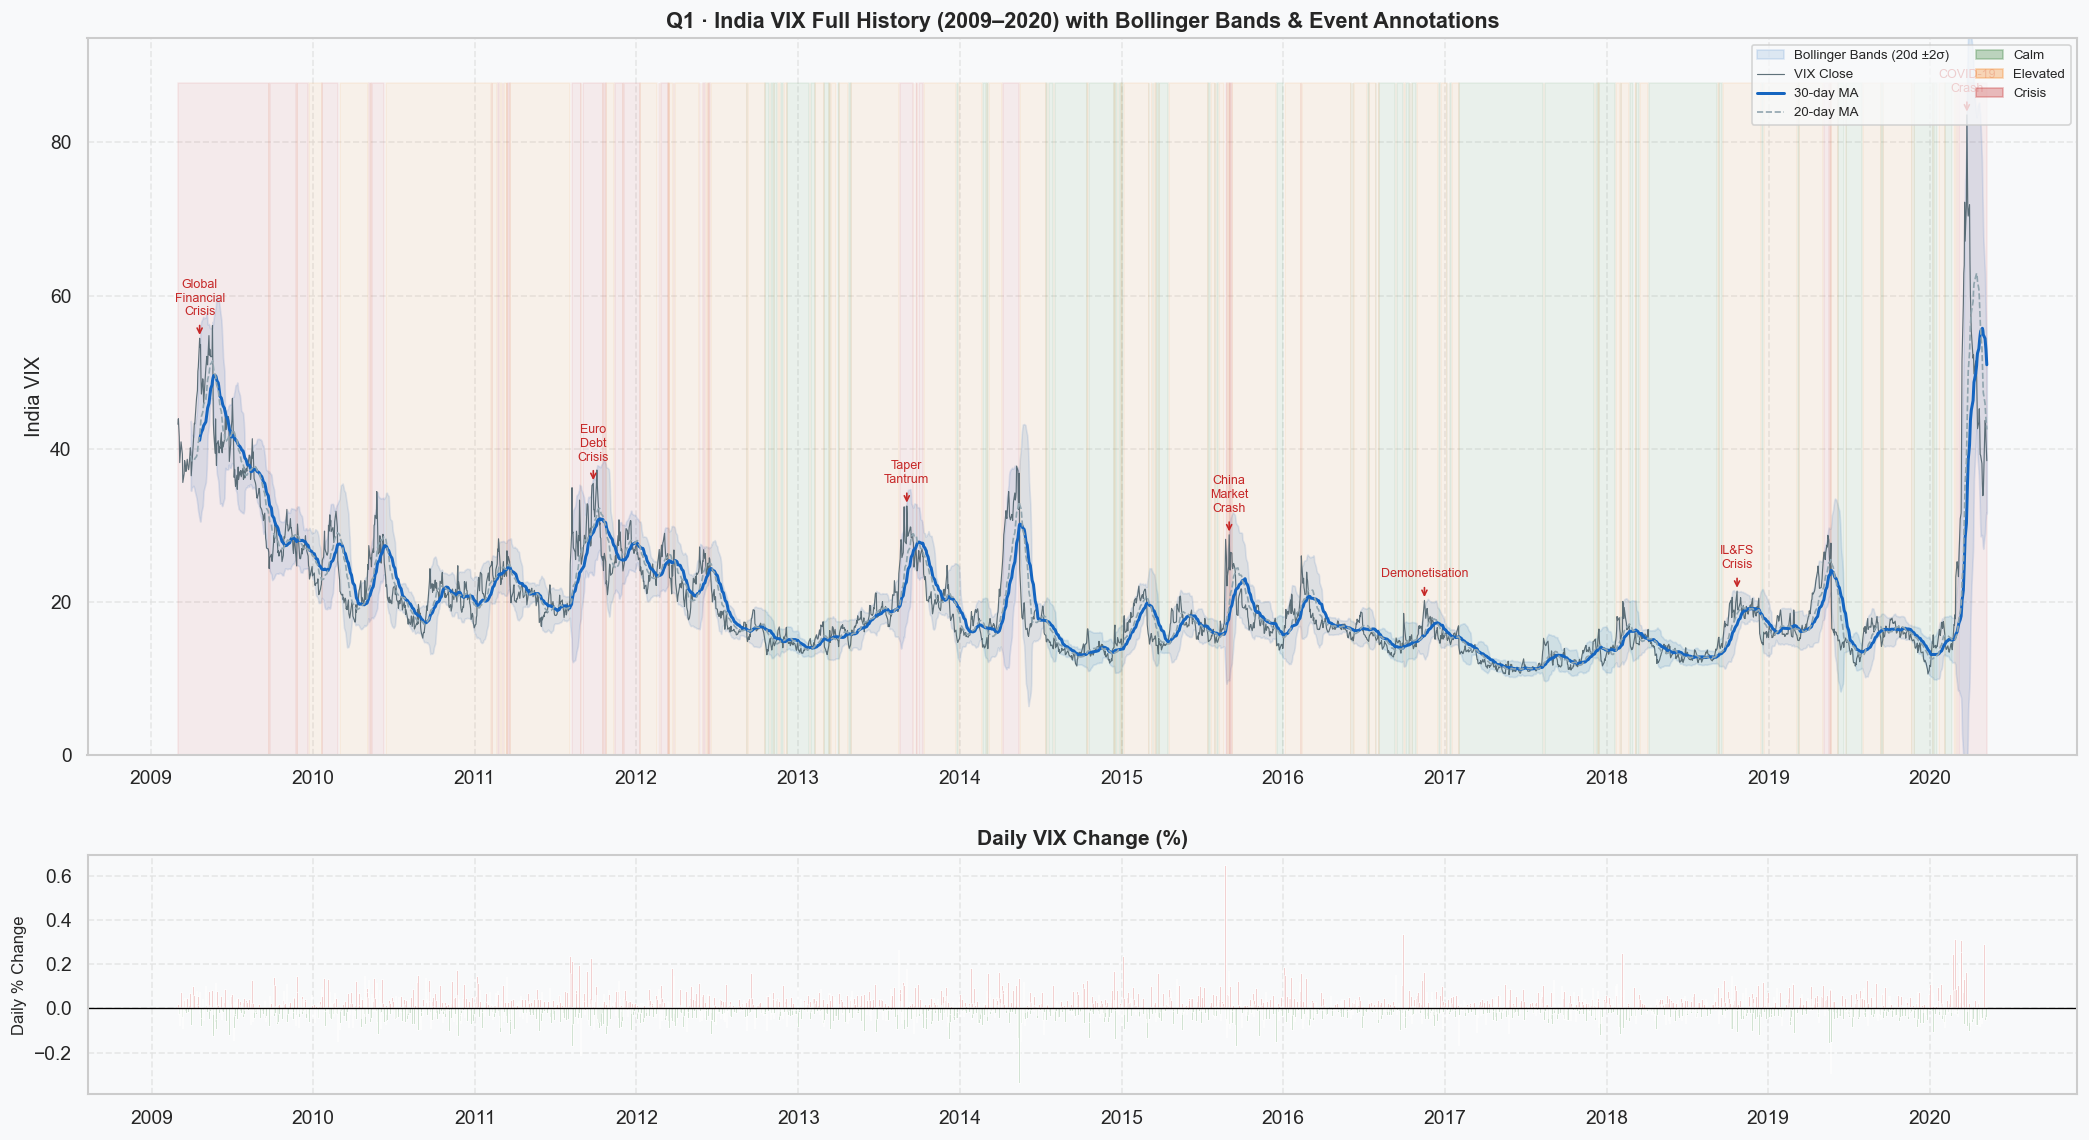

All-time High  : 83.61  on  2020-03-24
All-time Low   : 10.45  on  2017-05-25
Overall Mean   : 19.77
Overall Median : 17.27


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10),
                          gridspec_kw={'height_ratios': [3, 1]})

# ── Panel 1: full VIX series + rolling mean + Bollinger Bands ─────────────
ax = axes[0]
ax.fill_between(df['Date'], df['bb_lower'], df['bb_upper'],
                alpha=0.12, color=PAL['neutral'], label='Bollinger Bands (20d ±2σ)')
ax.plot(df['Date'], df['Close'],    color='#455A64', linewidth=0.7, alpha=0.85, label='VIX Close')
ax.plot(df['Date'], df['roll30_mean'], color=PAL['neutral'],  linewidth=1.8, label='30-day MA')
ax.plot(df['Date'], df['bb_mid'],   color='#90A4AE', linewidth=1,   linestyle='--', label='20-day MA')

# Regime background shading
for regime, color in REGIME_COLORS.items():
    mask = df['regime'] == regime
    ax.fill_between(df['Date'], 0, df['Close'].max()*1.05,
                    where=mask, alpha=0.07, color=color)

# Annotate major spikes
EVENTS = {
    '2009-03': ('Global\nFinancial\nCrisis', 80),
    '2011-08': ('Euro\nDebt\nCrisis', 55),
    '2013-08': ('Taper\nTantrum', 48),
    '2015-08': ('China\nMarket\nCrash', 42),
    '2016-11': ('Demonetisation', 45),
    '2018-10': ('IL&FS\nCrisis', 38),
    '2020-03': ('COVID-19\nCrash', 85),
}
for date_str, (label, y_offset) in EVENTS.items():
    event_date = pd.Timestamp(date_str)
    mask = (df['Date'] >= event_date) & (df['Date'] <= event_date + pd.DateOffset(months=2))
    sub = df[mask]
    if len(sub):
        peak_idx = sub['Close'].idxmax()
        peak_date = df.loc[peak_idx, 'Date']
        peak_val  = df.loc[peak_idx, 'Close']
        ax.annotate(label,
                    xy=(peak_date, peak_val),
                    xytext=(peak_date, peak_val + 3),
                    fontsize=7.5, ha='center', color=PAL['bear'],
                    arrowprops=dict(arrowstyle='->', color=PAL['bear'], lw=1))

ax.set_ylim(0, df['Close'].max() * 1.12)
ax.set_ylabel('India VIX', fontsize=12)
ax.set_title('Q1 · India VIX Full History (2009–2020) with Bollinger Bands & Event Annotations',
             fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=9, loc='upper right')

# Regime legend
regime_patches = [mpatches.Patch(color=c, alpha=0.3, label=r)
                  for r, c in REGIME_COLORS.items()]
ax.legend(handles=ax.get_legend_handles_labels()[0] + regime_patches,
          labels =ax.get_legend_handles_labels()[1] + list(REGIME_COLORS.keys()),
          fontsize=8, loc='upper right', ncol=2)

# ── Panel 2: daily % change bar chart ─────────────────────────────────────
ax2 = axes[1]
colors_bar = [PAL['bear'] if x > 0 else PAL['bull'] for x in df['pct_change']]
ax2.bar(df['Date'], df['pct_change'], color=colors_bar, width=1.5, alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Daily % Change', fontsize=10)
ax2.set_title('Daily VIX Change (%)', fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q1_vix_full_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'All-time High  : {df.Close.max():.2f}  on  {df.loc[df.Close.idxmax(),"Date"].date()}')
print(f'All-time Low   : {df.Close.min():.2f}  on  {df.loc[df.Close.idxmin(),"Date"].date()}')
print(f'Overall Mean   : {df.Close.mean():.2f}')
print(f'Overall Median : {df.Close.median():.2f}')


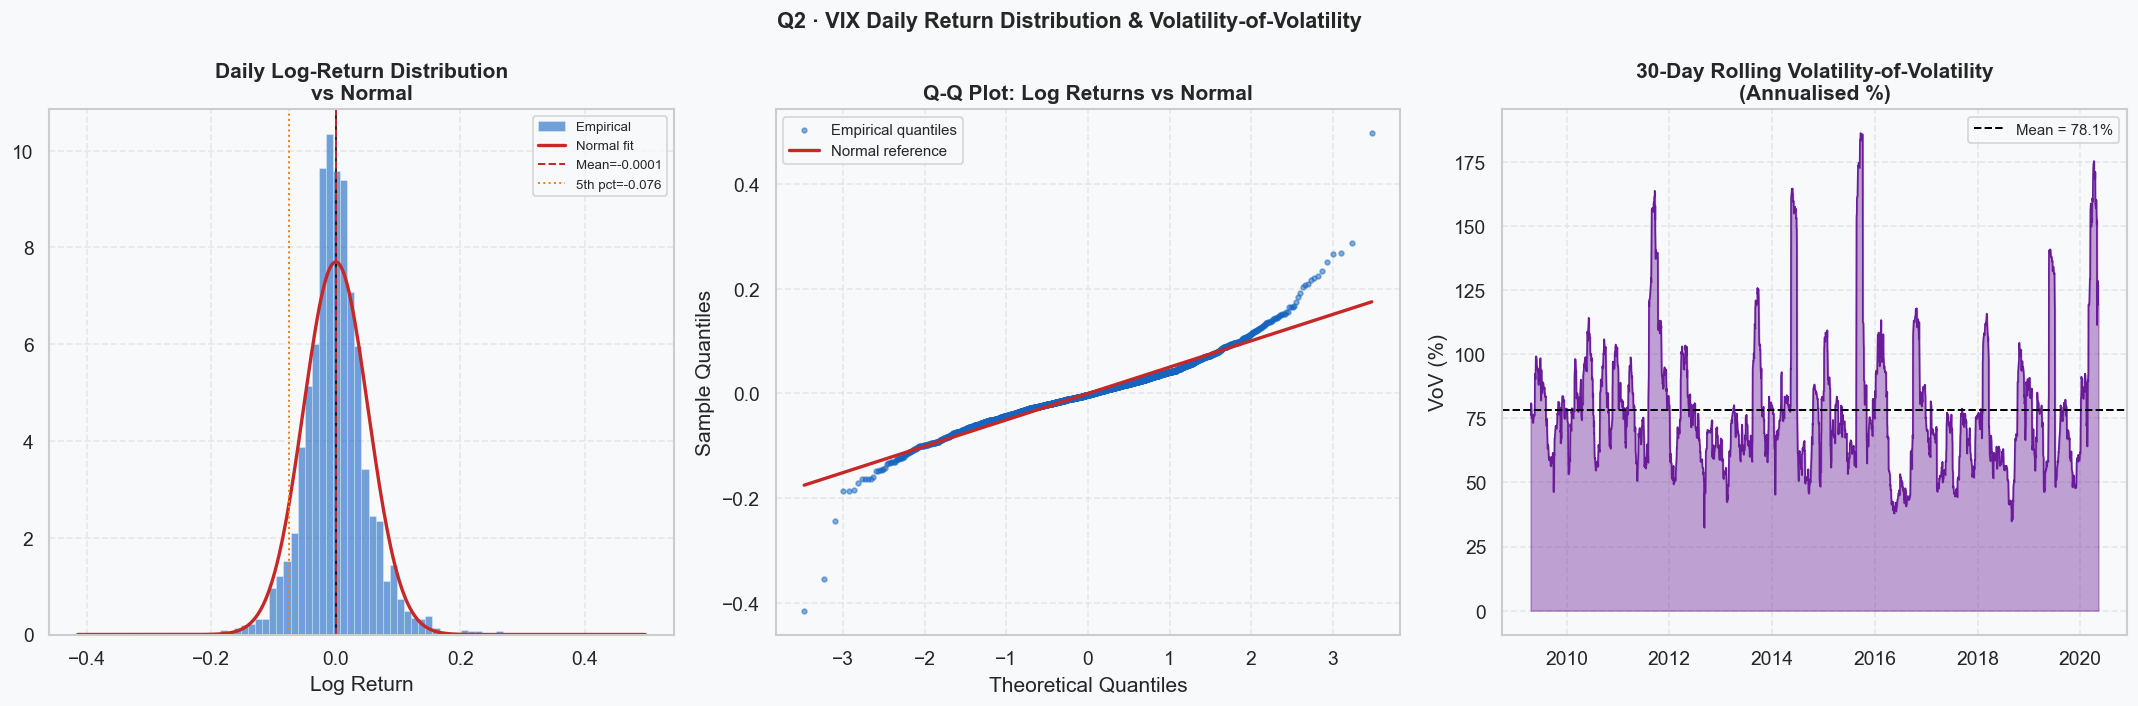

Skewness     : 0.4622   (positive = right-skewed fear spikes)
Excess Kurt. : 7.3220 (>0 = fat tails)
Normality test p-value: 7.78e-109  → ❌ NOT normal


In [7]:
lr = df['log_return'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Histogram vs Normal ───────────────────────────────────────────────────
ax = axes[0]
ax.hist(lr, bins=80, density=True, color=PAL['neutral'],
        alpha=0.6, edgecolor='white', linewidth=0.3, label='Empirical')
x_range = np.linspace(lr.min(), lr.max(), 300)
ax.plot(x_range, norm.pdf(x_range, lr.mean(), lr.std()),
        color=PAL['bear'], linewidth=2, label='Normal fit')
ax.axvline(0,           color='black',   linestyle='-',  linewidth=1)
ax.axvline(lr.mean(),   color=PAL['bear'],  linestyle='--', linewidth=1.2, label=f'Mean={lr.mean():.4f}')
ax.axvline(lr.quantile(0.05), color=PAL['warn'], linestyle=':', linewidth=1.2,
           label=f'5th pct={lr.quantile(0.05):.3f}')
ax.set_title('Daily Log-Return Distribution\nvs Normal', fontweight='bold')
ax.set_xlabel('Log Return')
ax.legend(fontsize=8)

# ── Q-Q Plot ──────────────────────────────────────────────────────────────
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(lr, dist='norm')
ax2.scatter(osm, osr, color=PAL['neutral'], s=8, alpha=0.5, label='Empirical quantiles')
ax2.plot(osm, slope*np.array(osm)+intercept, color=PAL['bear'],
         linewidth=2, label='Normal reference')
ax2.set_title('Q-Q Plot: Log Returns vs Normal', fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Sample Quantiles')
ax2.legend(fontsize=9)

# ── Rolling 30-day VoV ───────────────────────────────────────────────────
ax3 = axes[2]
vov = df['roll30_vol'].dropna()
ax3.fill_between(df.loc[vov.index, 'Date'], vov, alpha=0.4, color=PAL['purple'])
ax3.plot(df.loc[vov.index, 'Date'], vov, color=PAL['purple'], linewidth=1)
ax3.axhline(vov.mean(), color='black', linestyle='--', linewidth=1.2,
            label=f'Mean = {vov.mean():.1f}%')
ax3.set_title('30-Day Rolling Volatility-of-Volatility\n(Annualised %)', fontweight='bold')
ax3.set_ylabel('VoV (%)')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.legend(fontsize=9)

fig.suptitle('Q2 · VIX Daily Return Distribution & Volatility-of-Volatility',
             fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q2_return_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness     : {skew(lr):.4f}   (positive = right-skewed fear spikes)')
print(f'Excess Kurt. : {kurtosis(lr):.4f} (>0 = fat tails)')
_, p_normal = stats.normaltest(lr)
print(f'Normality test p-value: {p_normal:.2e}  → {"❌ NOT normal" if p_normal<0.05 else "✅ normal"}')


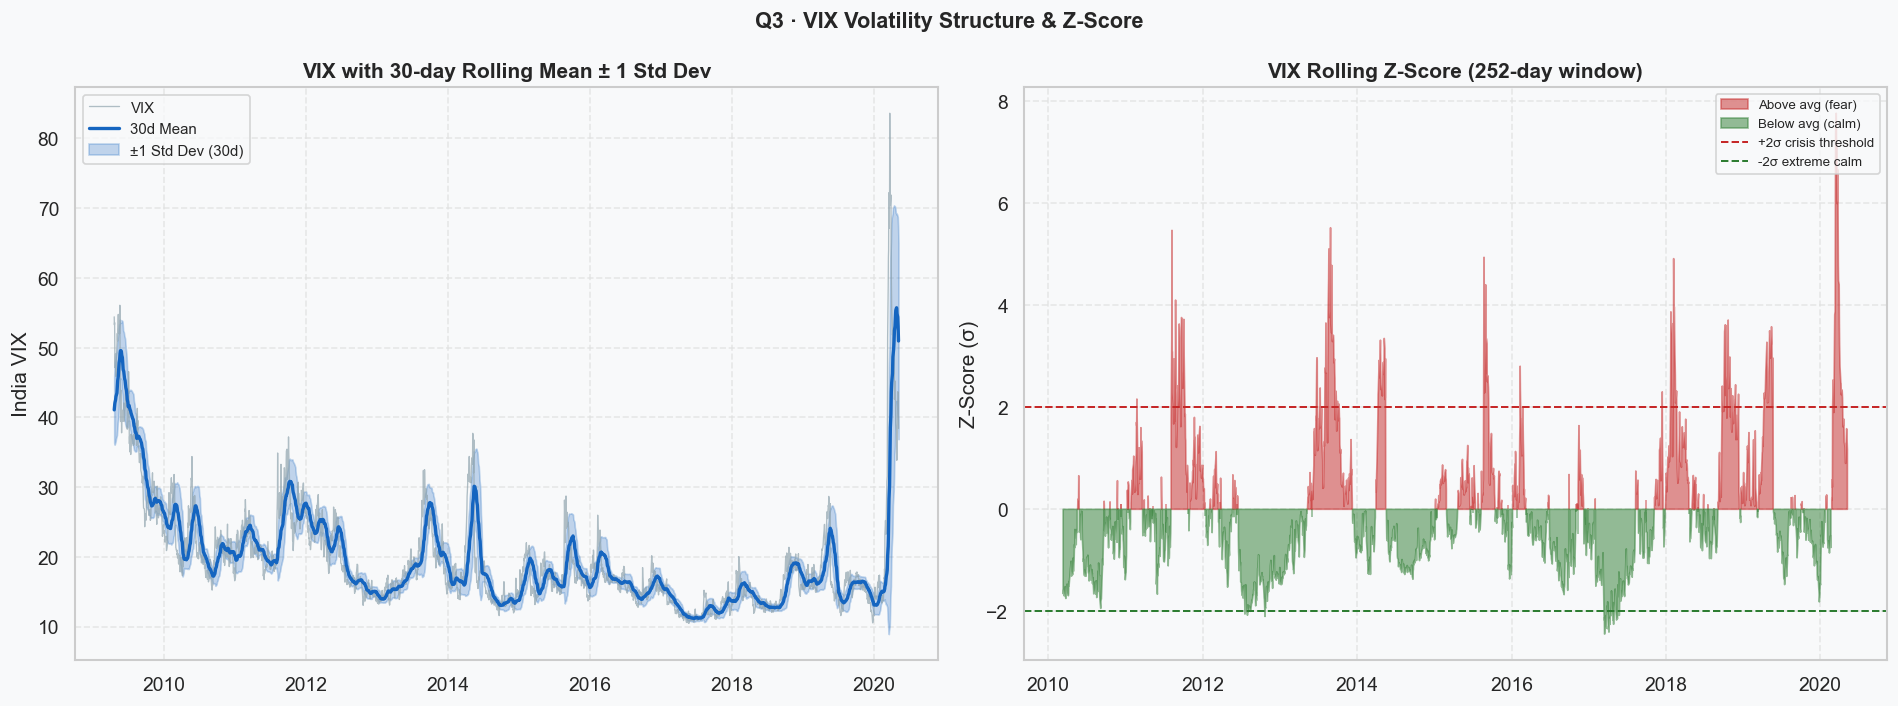

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── VIX + rolling std band ────────────────────────────────────────────────
ax = axes[0]
close_valid = df.dropna(subset=['roll30_mean','roll30_std'])
ax.plot(close_valid['Date'], close_valid['Close'],
        color='#90A4AE', linewidth=0.8, alpha=0.7, label='VIX')
ax.plot(close_valid['Date'], close_valid['roll30_mean'],
        color=PAL['neutral'], linewidth=2, label='30d Mean')
ax.fill_between(close_valid['Date'],
                close_valid['roll30_mean'] - close_valid['roll30_std'],
                close_valid['roll30_mean'] + close_valid['roll30_std'],
                alpha=0.25, color=PAL['neutral'], label='±1 Std Dev (30d)')
ax.set_title('VIX with 30-day Rolling Mean ± 1 Std Dev', fontweight='bold')
ax.set_ylabel('India VIX')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# ── VIX Z-score ───────────────────────────────────────────────────────────
ax2 = axes[1]
zscore_valid = df.dropna(subset=['zscore'])
ax2.fill_between(zscore_valid['Date'], zscore_valid['zscore'],
                 where=zscore_valid['zscore'] > 0,
                 color=PAL['bear'], alpha=0.5, label='Above avg (fear)')
ax2.fill_between(zscore_valid['Date'], zscore_valid['zscore'],
                 where=zscore_valid['zscore'] <= 0,
                 color=PAL['bull'], alpha=0.5, label='Below avg (calm)')
ax2.axhline(2,  color=PAL['bear'],  linestyle='--', linewidth=1.2, label='+2σ crisis threshold')
ax2.axhline(-2, color=PAL['bull'],  linestyle='--', linewidth=1.2, label='-2σ extreme calm')
ax2.set_title('VIX Rolling Z-Score (252-day window)', fontweight='bold')
ax2.set_ylabel('Z-Score (σ)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.legend(fontsize=8)

fig.suptitle('Q3 · VIX Volatility Structure & Z-Score', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q3_vix_volatility_zscore.png'), dpi=150, bbox_inches='tight')
plt.show()


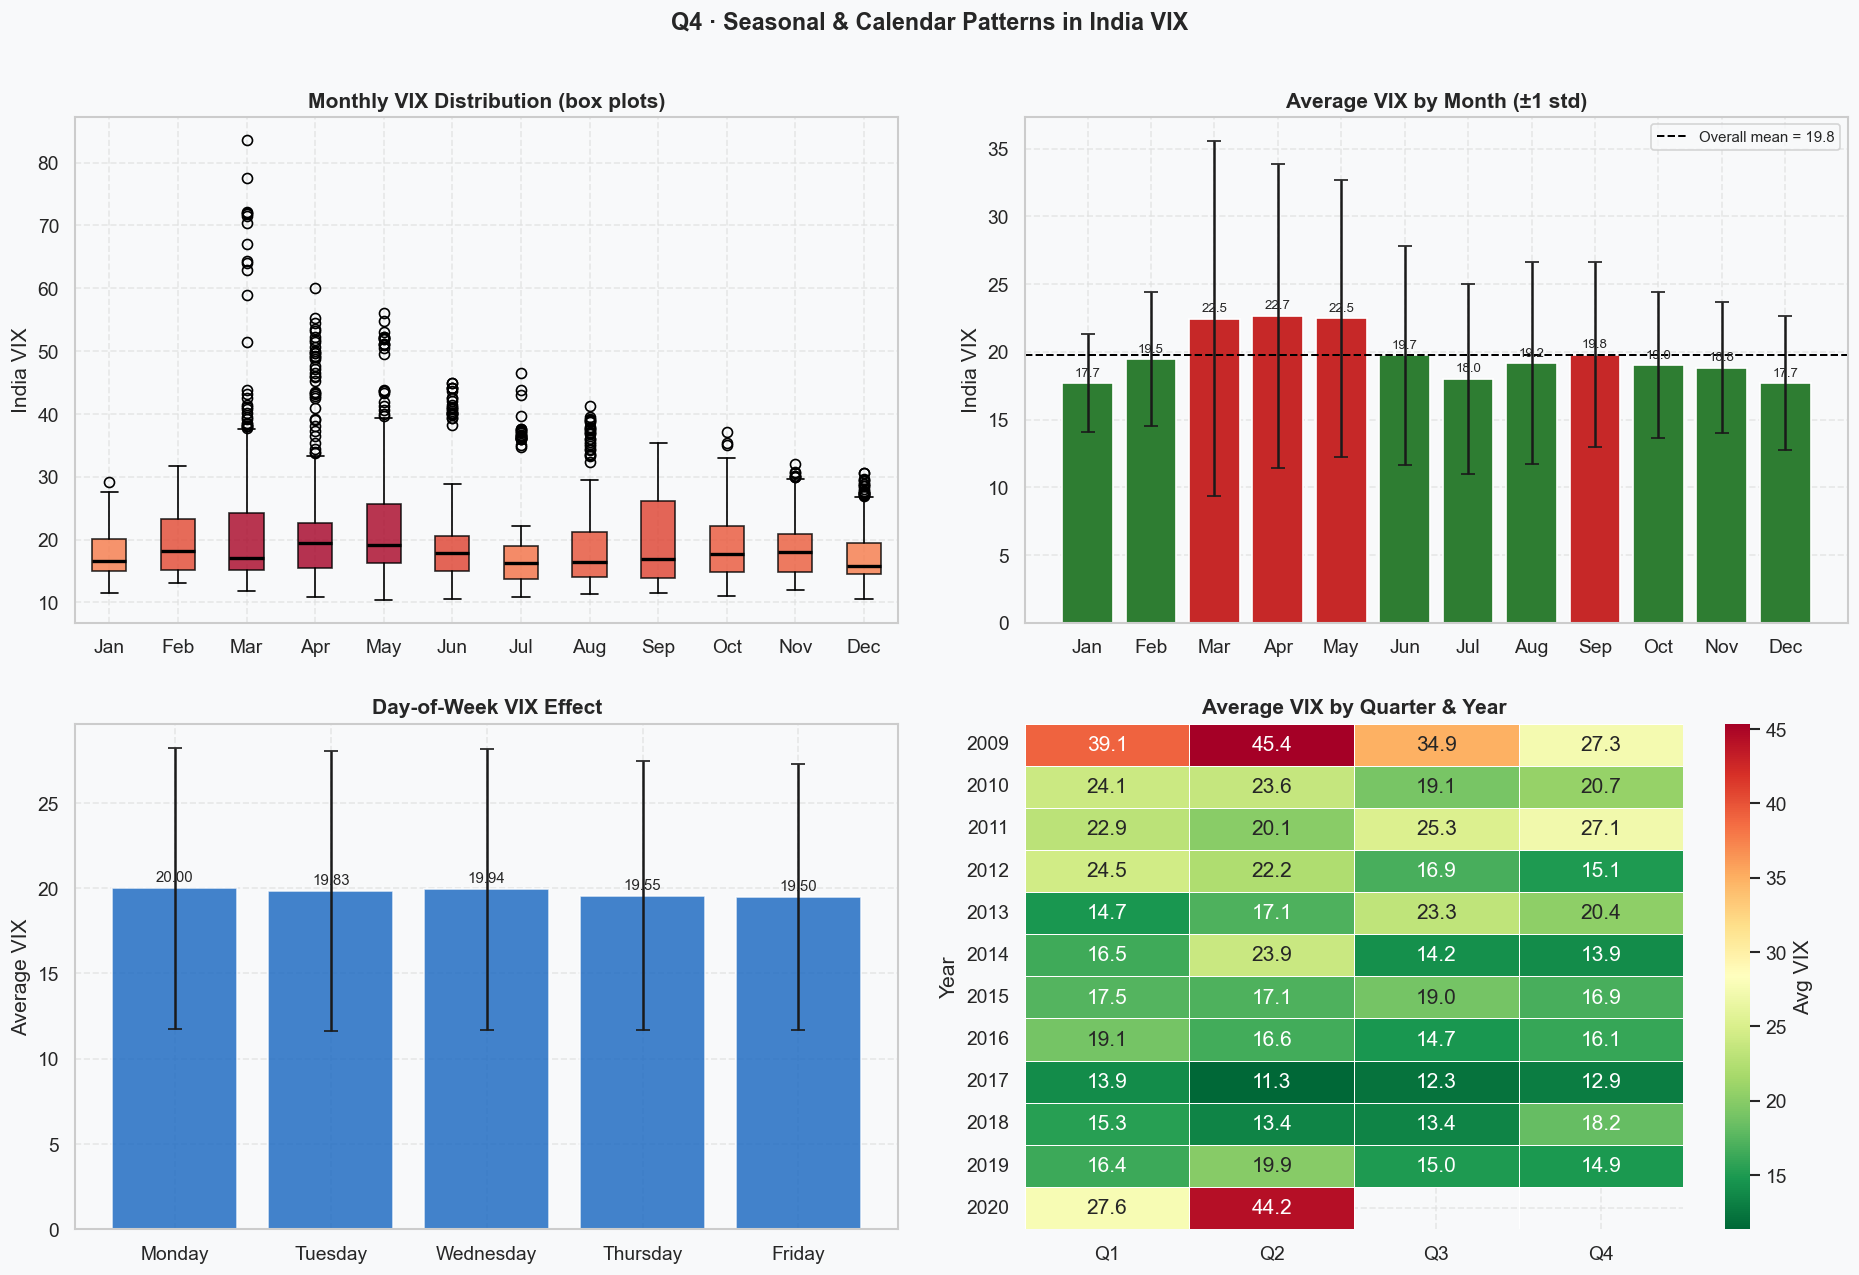

In [10]:
MONTH_ABBR = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Monthly box plots ─────────────────────────────────────────────────────
ax = axes[0,0]
monthly_data = [df[df['month']==m]['Close'].values for m in range(1,13)]
bp = ax.boxplot(monthly_data, patch_artist=True,
                medianprops={'color':'black','linewidth':2})
month_means = [d.mean() for d in monthly_data]
month_colors = plt.cm.RdYlGn_r(np.array(month_means) / max(month_means))
for patch, color in zip(bp['boxes'], month_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(MONTH_ABBR)
ax.set_title('Monthly VIX Distribution (box plots)', fontweight='bold')
ax.set_ylabel('India VIX')

# ── Monthly mean bar chart ────────────────────────────────────────────────
ax2 = axes[0,1]
m_means = df.groupby('month')['Close'].mean()
m_std   = df.groupby('month')['Close'].std()
bar_colors = [PAL['bear'] if v > df['Close'].mean() else PAL['bull']
              for v in m_means]
bars = ax2.bar(MONTH_ABBR, m_means.values, yerr=m_std.values,
               color=bar_colors, edgecolor='white', capsize=4)
ax2.axhline(df['Close'].mean(), color='black', linestyle='--',
            linewidth=1.2, label=f'Overall mean = {df.Close.mean():.1f}')
for bar, val in zip(bars, m_means.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax2.set_title('Average VIX by Month (±1 std)', fontweight='bold')
ax2.set_ylabel('India VIX')
ax2.legend(fontsize=9)

# ── Day-of-week effect ────────────────────────────────────────────────────
ax3 = axes[1,0]
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
dow_means = df[df['day_of_week'].isin(dow_order)]\
              .groupby('day_of_week')['Close']\
              .agg(['mean','std'])\
              .reindex(dow_order)
bar_dow = ax3.bar(dow_means.index, dow_means['mean'],
                  yerr=dow_means['std'],
                  color=PAL['neutral'], edgecolor='white',
                  alpha=0.8, capsize=4)
for bar, val in zip(bar_dow, dow_means['mean']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax3.set_title('Day-of-Week VIX Effect', fontweight='bold')
ax3.set_ylabel('Average VIX')

# ── Quarterly heatmap ─────────────────────────────────────────────────────
ax4 = axes[1,1]
pivot_qtr = df.pivot_table(values='Close', index='year',
                           columns='quarter', aggfunc='mean').round(2)
pivot_qtr.columns = ['Q1','Q2','Q3','Q4']
sns.heatmap(pivot_qtr, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax4, cbar_kws={'label':'Avg VIX'})
ax4.set_title('Average VIX by Quarter & Year', fontweight='bold')
ax4.set_ylabel('Year'); ax4.set_xlabel('')

fig.suptitle('Q4 · Seasonal & Calendar Patterns in India VIX',
             fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q4_seasonal_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()


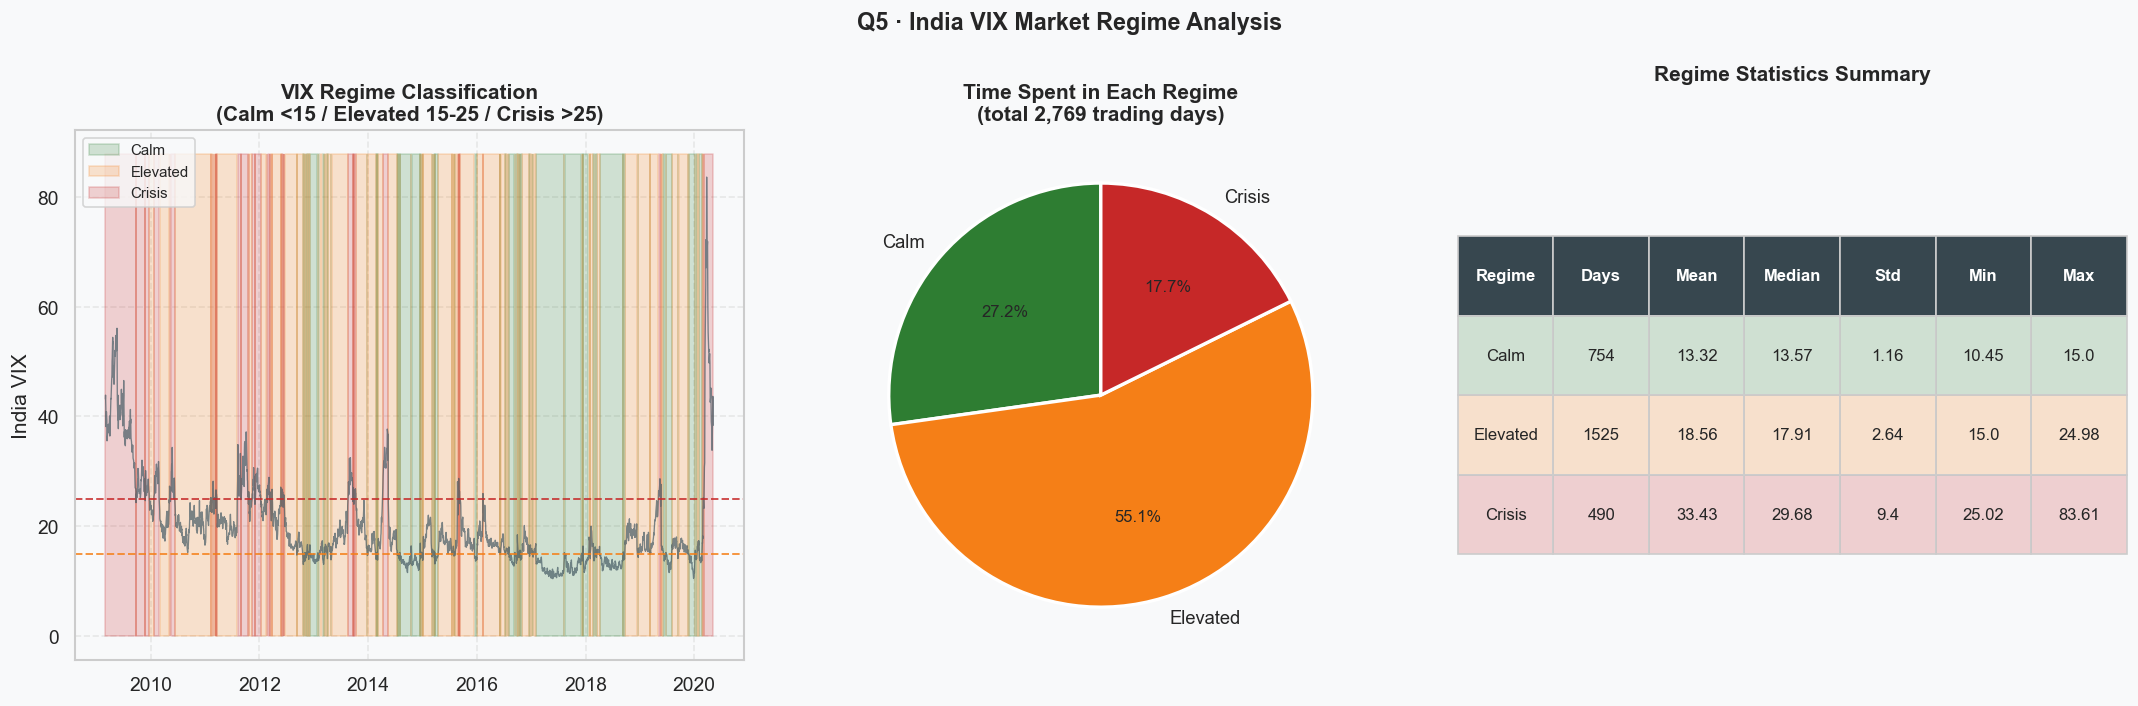

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Regime timeline ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['Date'], df['Close'], color='#455A64', linewidth=0.8, alpha=0.7)
for regime, color in REGIME_COLORS.items():
    mask = df['regime'] == regime
    ax.fill_between(df['Date'], 0, df['Close'].max()*1.05,
                    where=mask, color=color, alpha=0.2, label=regime)
ax.axhline(15, color=REGIME_COLORS['Elevated'], linestyle='--', linewidth=1.2, alpha=0.8)
ax.axhline(25, color=REGIME_COLORS['Crisis'],   linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_title('VIX Regime Classification\n(Calm <15 / Elevated 15-25 / Crisis >25)',
             fontweight='bold')
ax.set_ylabel('India VIX')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# ── Regime pie chart ──────────────────────────────────────────────────────
ax2 = axes[1]
regime_counts = df['regime'].value_counts()[['Calm','Elevated','Crisis']]
wedges, texts, autotexts = ax2.pie(
    regime_counts.values,
    labels=regime_counts.index,
    colors=[REGIME_COLORS[r] for r in regime_counts.index],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize':11},
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts: at.set_fontsize(10)
ax2.set_title(f'Time Spent in Each Regime\n(total {len(df):,} trading days)',
              fontweight='bold')

# ── Regime stats table ────────────────────────────────────────────────────
ax3 = axes[2]
ax3.axis('off')
regime_stats = df.groupby('regime')['Close'].agg(
    Days='count', Mean='mean', Median='median', Std='std', Min='min', Max='max'
).round(2).reindex(['Calm','Elevated','Crisis'])
regime_stats['Days'] = regime_stats['Days'].astype(int)

tbl = ax3.table(
    cellText=regime_stats.reset_index().values,
    colLabels=['Regime'] + regime_stats.columns.tolist(),
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.6]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif r > 0:
        regime_name = regime_stats.index[r-1]
        cell.set_facecolor(REGIME_COLORS[regime_name] + '33')
ax3.set_title('Regime Statistics Summary', fontweight='bold', pad=30)

fig.suptitle('Q5 · India VIX Market Regime Analysis', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q5_regime_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


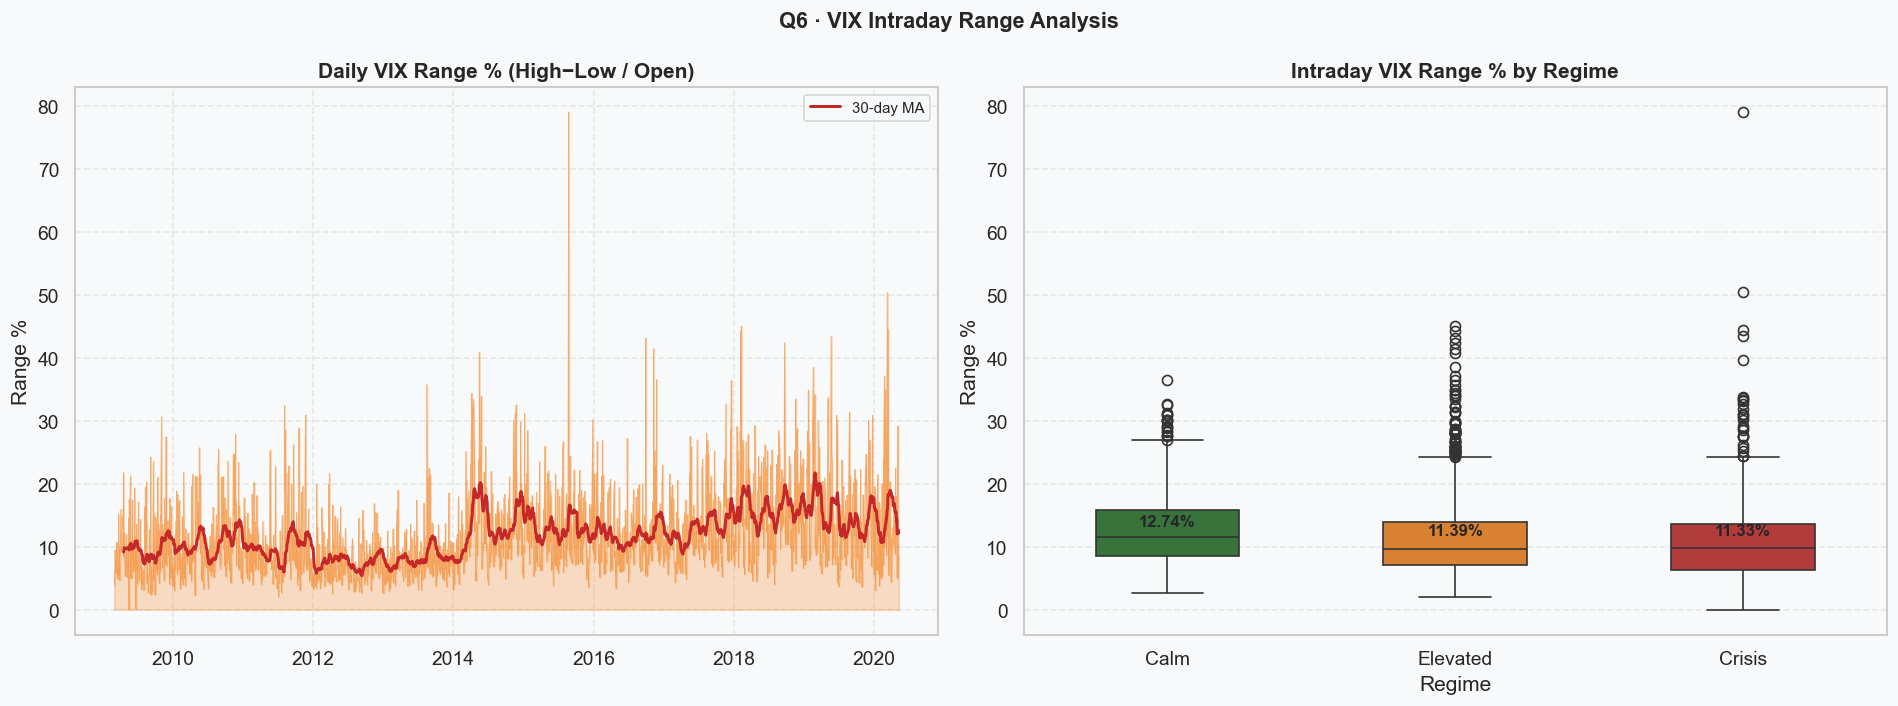

Top 10 highest-range days:
      Date    Open    High     Low   Close  range_pct   regime
2015-08-24 17.1150 30.6525 17.1150 28.1300  79.097283   Crisis
2020-03-09 25.6425 34.3550 21.4250 30.8000  50.424101   Crisis
2018-02-08 19.4650 24.0350 15.2625 17.7725  45.068071 Elevated
2020-03-13 41.1625 59.4825 41.1625 51.4725  44.506529   Crisis
2018-02-06 16.0525 23.1575 16.0525 20.0150  44.261019 Elevated
2019-05-22 25.6525 30.1825 19.0400 27.6325  43.436312   Crisis
2016-09-29 13.8475 19.1250 13.1525 18.4500  43.130529 Elevated
2018-09-21 14.0050 16.9200 10.9825 15.5350  42.395573 Elevated
2016-11-09 16.7700 22.7900 15.8400 16.6200  41.443053 Elevated
2014-05-16 36.7650 36.7650 21.7375 24.2925  40.874473 Elevated


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Range % over time ─────────────────────────────────────────────────────
ax = axes[0]
roll_range = df['range_pct'].rolling(30).mean()
ax.fill_between(df['Date'], df['range_pct'], alpha=0.25, color=PAL['warn'])
ax.plot(df['Date'], df['range_pct'], color=PAL['warn'], linewidth=0.5, alpha=0.5)
ax.plot(df['Date'], roll_range, color=PAL['bear'], linewidth=1.8, label='30-day MA')
ax.set_title('Daily VIX Range % (High−Low / Open)', fontweight='bold')
ax.set_ylabel('Range %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# ── Range % by regime ─────────────────────────────────────────────────────
ax2 = axes[1]
sns.boxplot(data=df, x='regime', y='range_pct',
            order=['Calm','Elevated','Crisis'],
            palette=REGIME_COLORS, ax=ax2, width=0.5)
for i, regime in enumerate(['Calm','Elevated','Crisis']):
    m = df[df['regime']==regime]['range_pct'].mean()
    ax2.text(i, m+0.05, f'{m:.2f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.set_title('Intraday VIX Range % by Regime', fontweight='bold')
ax2.set_xlabel('Regime'); ax2.set_ylabel('Range %')

fig.suptitle('Q6 · VIX Intraday Range Analysis', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q6_intraday_range.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 highest-range days:')
print(df.nlargest(10,'range_pct')[['Date','Open','High','Low','Close','range_pct','regime']]
      .to_string(index=False))


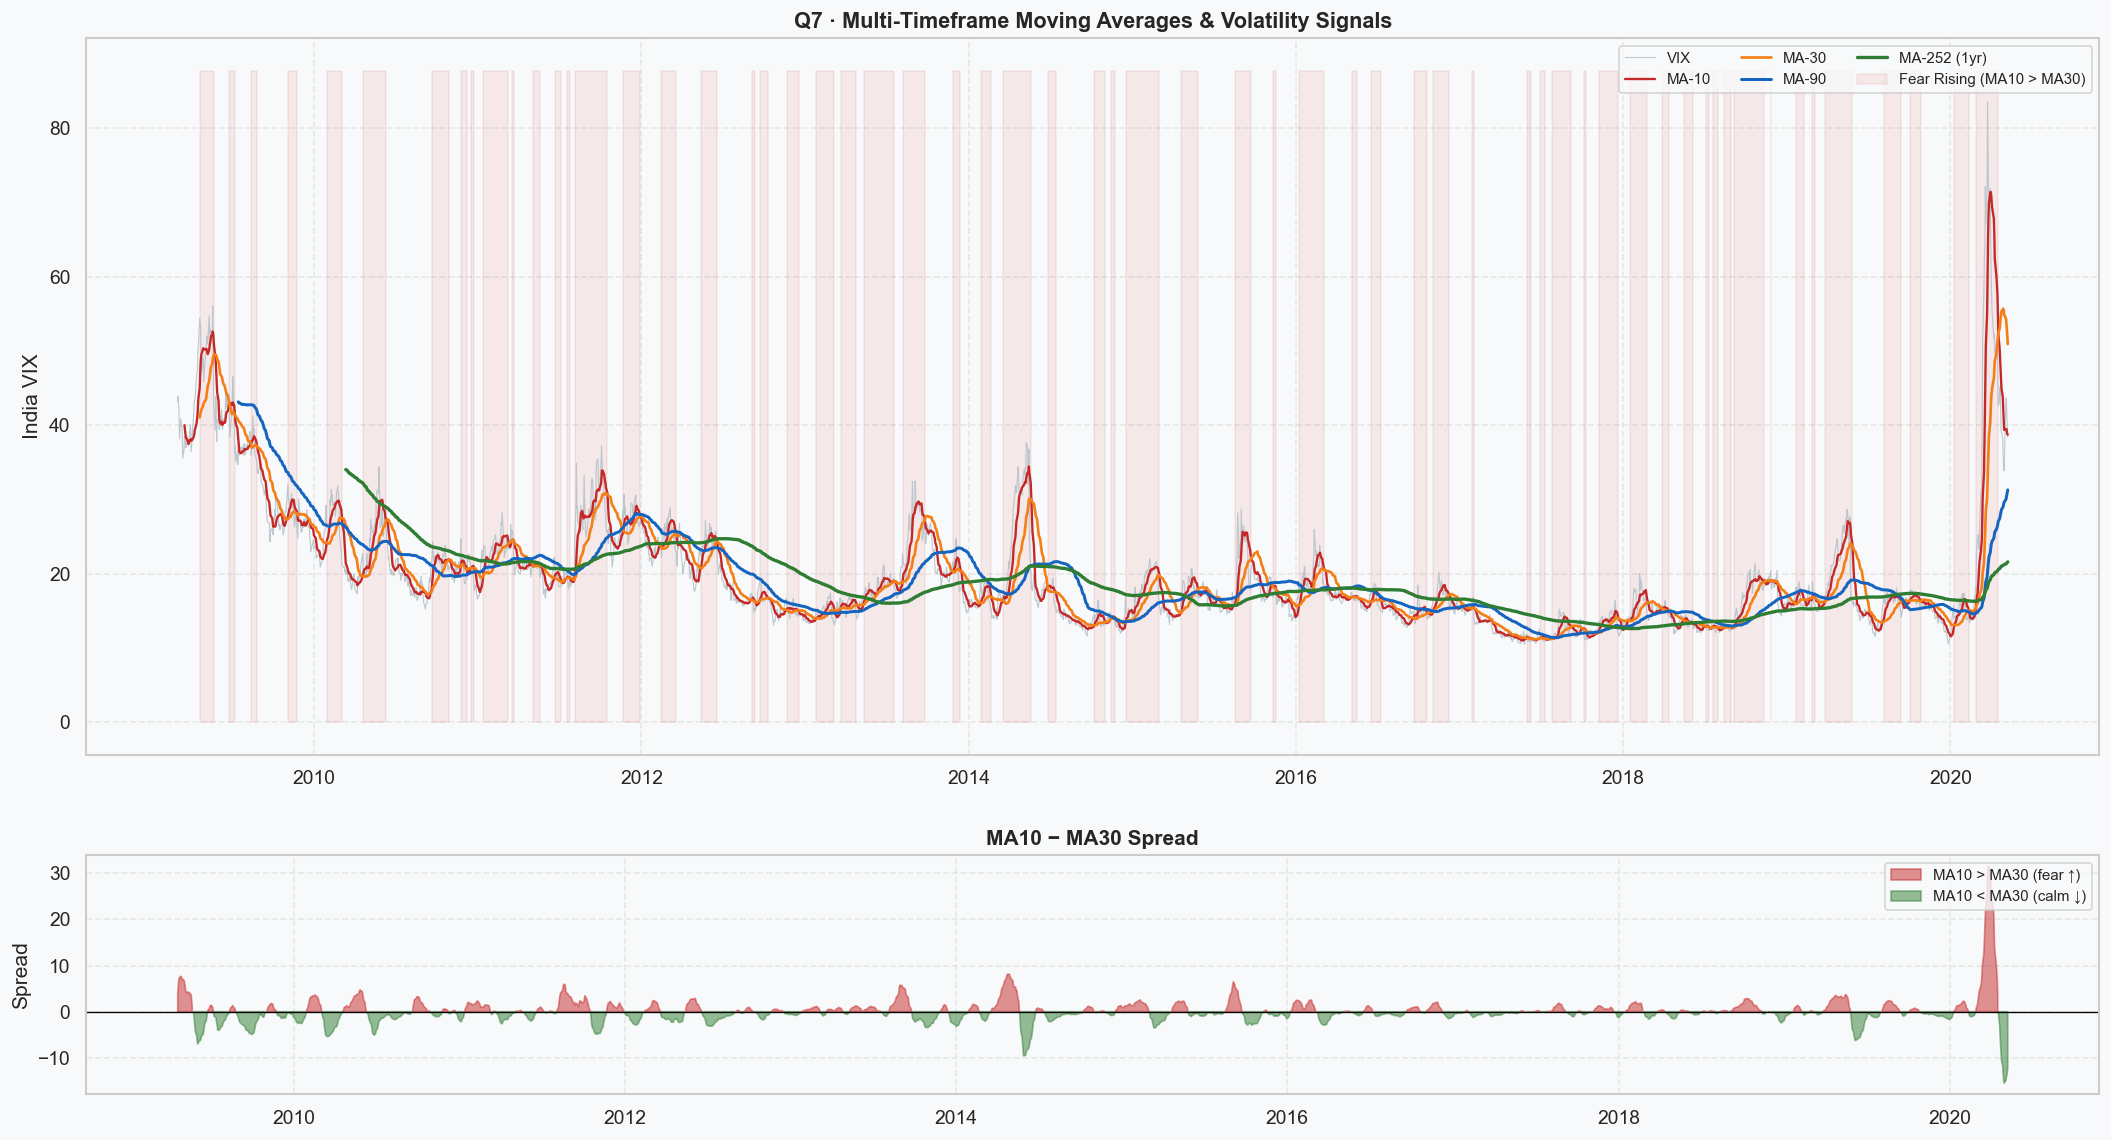

In [13]:
df['ma10']  = df['Close'].rolling(10).mean()
df['ma30']  = df['Close'].rolling(30).mean()
df['ma90']  = df['Close'].rolling(90).mean()
df['ma252'] = df['Close'].rolling(252).mean()

# Golden/Death cross: MA10 vs MA30
df['signal'] = np.where(df['ma10'] > df['ma30'], 'Fear Rising', 'Fear Falling')

fig, axes = plt.subplots(2, 1, figsize=(18, 10),
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(df['Date'], df['Close'],  color='#B0BEC5', linewidth=0.7, alpha=0.8, label='VIX')
ax.plot(df['Date'], df['ma10'],   color=PAL['bear'],    linewidth=1.4, label='MA-10')
ax.plot(df['Date'], df['ma30'],   color=PAL['warn'],    linewidth=1.6, label='MA-30')
ax.plot(df['Date'], df['ma90'],   color=PAL['neutral'], linewidth=1.8, label='MA-90')
ax.plot(df['Date'], df['ma252'],  color=PAL['bull'],    linewidth=2.0, label='MA-252 (1yr)')

# Shade fear-rising periods
fear_rising = df['signal'] == 'Fear Rising'
ax.fill_between(df['Date'], 0, df['Close'].max()*1.05,
                where=fear_rising, alpha=0.08, color=PAL['bear'],
                label='Fear Rising (MA10 > MA30)')

ax.set_title('Q7 · Multi-Timeframe Moving Averages & Volatility Signals',
             fontweight='bold', fontsize=13)
ax.set_ylabel('India VIX')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9, loc='upper right', ncol=3)

# ── MA10-MA30 spread ──────────────────────────────────────────────────────
ax2 = axes[1]
spread = df['ma10'] - df['ma30']
ax2.fill_between(df['Date'], spread,
                 where=spread > 0, color=PAL['bear'], alpha=0.5, label='MA10 > MA30 (fear ↑)')
ax2.fill_between(df['Date'], spread,
                 where=spread <= 0, color=PAL['bull'], alpha=0.5, label='MA10 < MA30 (calm ↓)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('MA10 − MA30 Spread', fontweight='bold')
ax2.set_ylabel('Spread')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.legend(fontsize=9)

fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q7_moving_averages.png'), dpi=150, bbox_inches='tight')
plt.show()


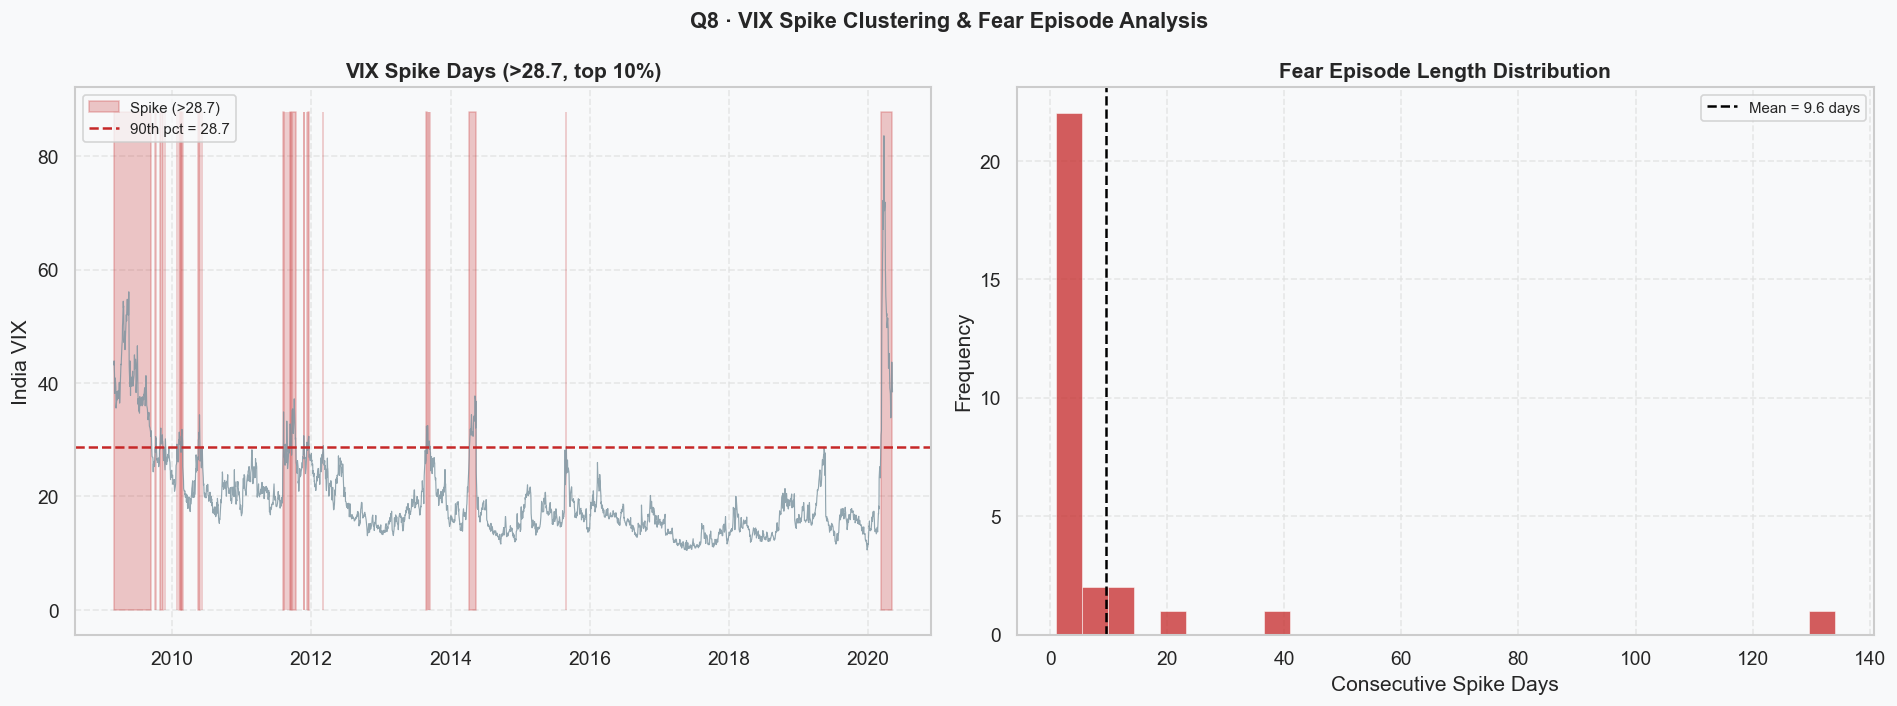

Total spike days    : 277 (10.0%)
Number of episodes  : 29
Mean episode length : 9.6 days
Longest episode     : 134 days

Spike days per year:
year
2009    149
2010     22
2011     34
2012      1
2013      9
2014     22
2015      1
2020     39


In [14]:
SPIKE_THRESH = df['Close'].quantile(0.90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Spike timeline ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['Date'], df['Close'], color='#78909C', linewidth=0.7, alpha=0.8)
spike_mask = df['is_spike']
ax.fill_between(df['Date'], 0, df['Close'].max()*1.05,
                where=spike_mask, color=PAL['bear'], alpha=0.25, label=f'Spike (>{SPIKE_THRESH:.1f})')
ax.axhline(SPIKE_THRESH, color=PAL['bear'], linestyle='--', linewidth=1.5,
           label=f'90th pct = {SPIKE_THRESH:.1f}')
ax.set_title(f'VIX Spike Days (>{SPIKE_THRESH:.1f}, top 10%)', fontweight='bold')
ax.set_ylabel('India VIX')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# ── Episode length distribution ───────────────────────────────────────────
ax2 = axes[1]
# Identify consecutive spike episodes
df['spike_episode'] = (df['is_spike'] != df['is_spike'].shift()).cumsum()
episodes = df[df['is_spike']].groupby('spike_episode').size()
ax2.hist(episodes.values, bins=30, color=PAL['bear'], edgecolor='white',
         alpha=0.75, linewidth=0.4)
ax2.axvline(episodes.mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Mean = {episodes.mean():.1f} days')
ax2.set_title('Fear Episode Length Distribution', fontweight='bold')
ax2.set_xlabel('Consecutive Spike Days')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=9)

fig.suptitle('Q8 · VIX Spike Clustering & Fear Episode Analysis',
             fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q8_spike_clustering.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Total spike days    : {df.is_spike.sum()} ({df.is_spike.mean()*100:.1f}%)')
print(f'Number of episodes  : {len(episodes)}')
print(f'Mean episode length : {episodes.mean():.1f} days')
print(f'Longest episode     : {episodes.max()} days')
print(f'\nSpike days per year:')
print(df[df.is_spike].groupby('year').size().to_string())


Mean-reversion speed: 0.0130  (closer to 1 = faster reversion)


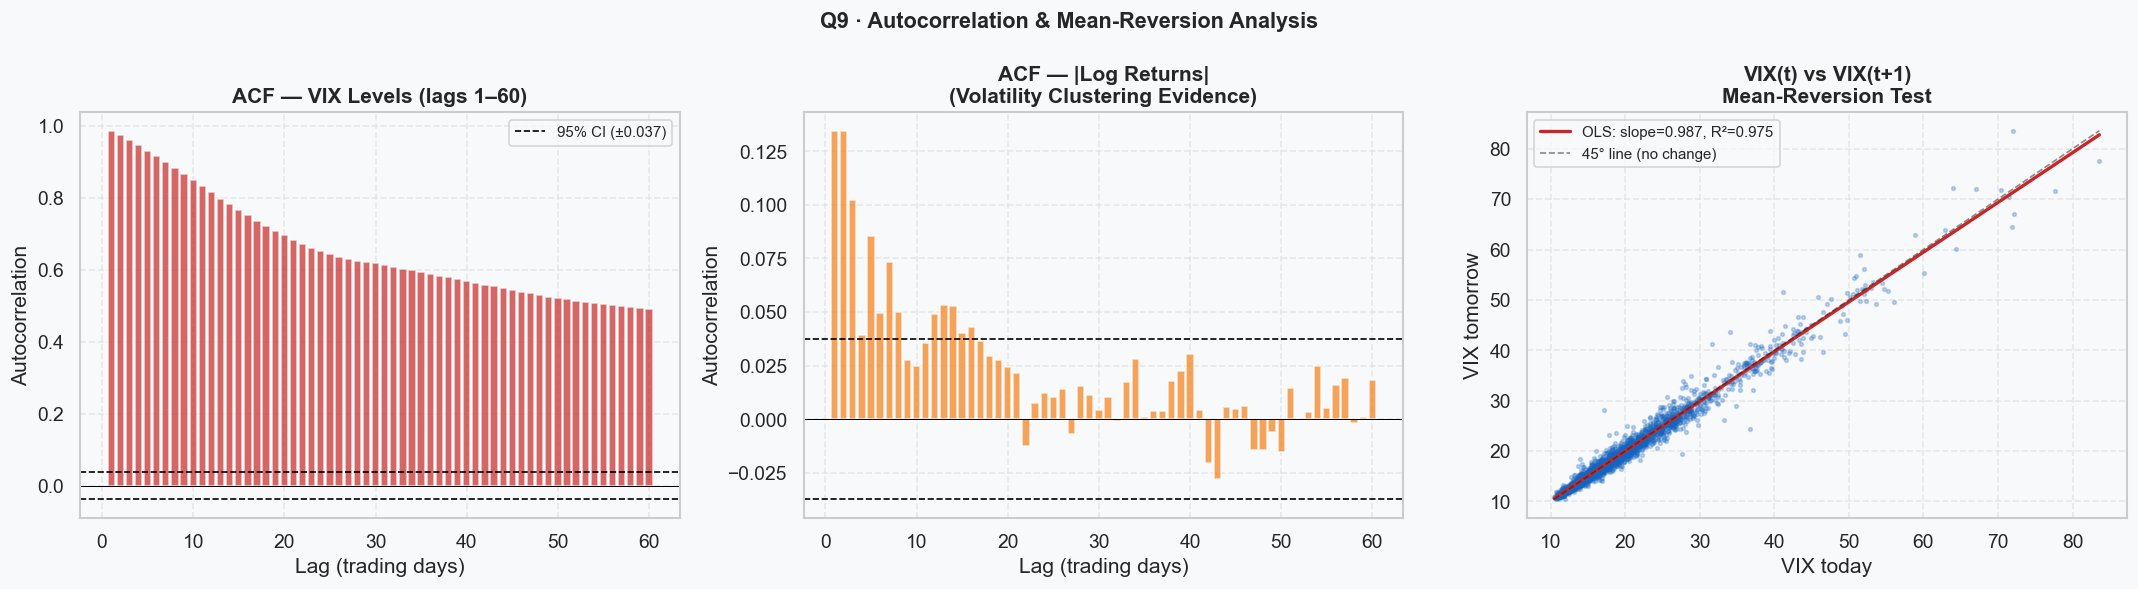


Lag-1 autocorrelation (levels)  : 0.9876
Lag-5 autocorrelation (levels)  : 0.9322
Lag-1 autocorrelation (|return|): 0.1345  (volatility clustering)
OLS slope VIX(t→t+1)           : 0.9870  → mean-reversion speed = 0.0130


In [15]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ACF of VIX levels ─────────────────────────────────────────────────────
ax = axes[0]
max_lags = 60
acf_vals = [df['Close'].autocorr(lag=i) for i in range(1, max_lags+1)]
ax.bar(range(1, max_lags+1), acf_vals,
       color=[PAL['bear'] if v > 0 else PAL['bull'] for v in acf_vals],
       alpha=0.7, width=0.8)
ci = 1.96 / np.sqrt(len(df))
ax.axhline( ci, color='black', linestyle='--', linewidth=1, label=f'95% CI (±{ci:.3f})')
ax.axhline(-ci, color='black', linestyle='--', linewidth=1)
ax.axhline(0,   color='black', linewidth=0.6)
ax.set_title('ACF — VIX Levels (lags 1–60)', fontweight='bold')
ax.set_xlabel('Lag (trading days)'); ax.set_ylabel('Autocorrelation')
ax.legend(fontsize=9)

# ── ACF of absolute returns (volatility clustering) ───────────────────────
ax2 = axes[1]
abs_ret = df['log_return'].abs().dropna()
acf_abs = [abs_ret.autocorr(lag=i) for i in range(1, max_lags+1)]
ax2.bar(range(1, max_lags+1), acf_abs, color=PAL['warn'], alpha=0.7, width=0.8)
ax2.axhline( ci, color='black', linestyle='--', linewidth=1)
ax2.axhline(-ci, color='black', linestyle='--', linewidth=1)
ax2.axhline(0,   color='black', linewidth=0.6)
ax2.set_title('ACF — |Log Returns|\n(Volatility Clustering Evidence)', fontweight='bold')
ax2.set_xlabel('Lag (trading days)'); ax2.set_ylabel('Autocorrelation')

# ── Mean-reversion scatter: VIX(t) vs VIX(t+1) ───────────────────────────
ax3 = axes[2]
x = df['Close'].values[:-1]
y = df['Close'].values[1:]
ax3.scatter(x, y, s=5, alpha=0.25, color=PAL['neutral'])
slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax3.plot(x_line, slope*x_line+intercept, color=PAL['bear'], linewidth=2,
         label=f'OLS: slope={slope:.3f}, R²={r**2:.3f}')
ax3.plot(x_line, x_line, 'k--', linewidth=1, alpha=0.5, label='45° line (no change)')
ax3.set_title(f'VIX(t) vs VIX(t+1)\nMean-Reversion Test', fontweight='bold')
ax3.set_xlabel('VIX today'); ax3.set_ylabel('VIX tomorrow')
ax3.legend(fontsize=9)

mr_speed = 1 - slope
print(f'Mean-reversion speed: {mr_speed:.4f}  (closer to 1 = faster reversion)')

fig.suptitle('Q9 · Autocorrelation & Mean-Reversion Analysis',
             fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q9_autocorrelation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nLag-1 autocorrelation (levels)  : {df.Close.autocorr(1):.4f}')
print(f'Lag-5 autocorrelation (levels)  : {df.Close.autocorr(5):.4f}')
print(f'Lag-1 autocorrelation (|return|): {abs_ret.autocorr(1):.4f}  (volatility clustering)')
print(f'OLS slope VIX(t→t+1)           : {slope:.4f}  → mean-reversion speed = {mr_speed:.4f}')


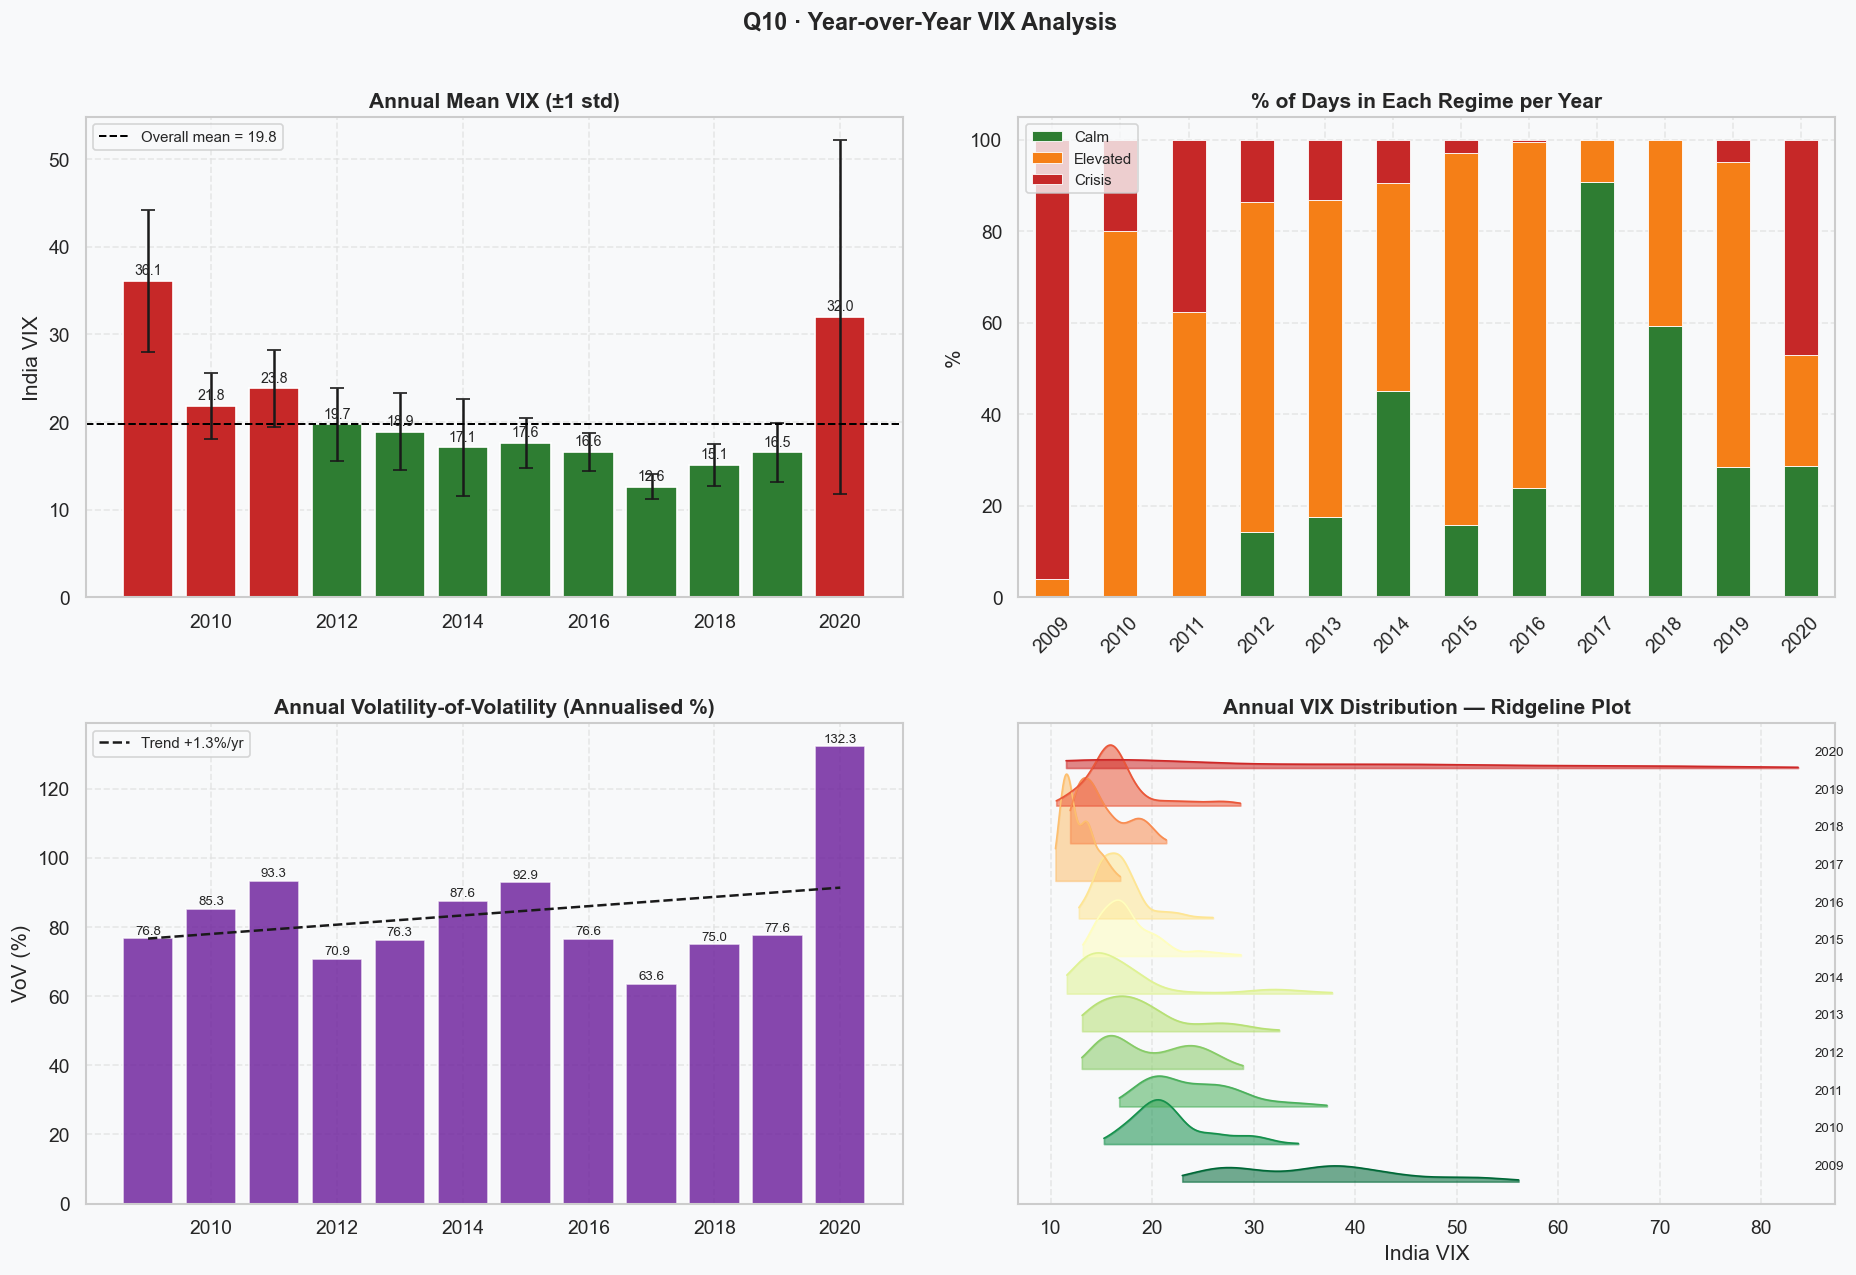

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Annual mean + std ─────────────────────────────────────────────────────
ax = axes[0,0]
ann = df.groupby('year')['Close'].agg(['mean','std','median'])
bar_colors = [PAL['bear'] if v > df.Close.mean() else PAL['bull'] for v in ann['mean']]
bars = ax.bar(ann.index, ann['mean'], yerr=ann['std'],
              color=bar_colors, edgecolor='white', capsize=4)
ax.axhline(df.Close.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Overall mean = {df.Close.mean():.1f}')
for bar, val in zip(bars, ann['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8.5)
ax.set_title('Annual Mean VIX (±1 std)', fontweight='bold')
ax.set_ylabel('India VIX'); ax.legend(fontsize=9)

# ── Annual % of days in each regime ───────────────────────────────────────
ax2 = axes[0,1]
reg_pct = df.groupby(['year','regime']).size().unstack(fill_value=0)
reg_pct = reg_pct.div(reg_pct.sum(axis=1), axis=0) * 100
for col in ['Calm','Elevated','Crisis']:
    if col not in reg_pct.columns:
        reg_pct[col] = 0
reg_pct = reg_pct[['Calm','Elevated','Crisis']]
reg_pct.plot(kind='bar', stacked=True, ax=ax2,
             color=[REGIME_COLORS[r] for r in ['Calm','Elevated','Crisis']],
             edgecolor='white', linewidth=0.5)
ax2.set_title('% of Days in Each Regime per Year', fontweight='bold')
ax2.set_ylabel('%'); ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.legend(fontsize=9)

# ── Annual VoV (ann. std of log returns) ──────────────────────────────────
ax3 = axes[1,0]
ann_vov = df.groupby('year')['log_return'].std() * np.sqrt(252) * 100
slope_v, intercept_v, _, _, _ = stats.linregress(ann_vov.index, ann_vov.values)
ax3.bar(ann_vov.index, ann_vov.values, color=PAL['purple'],
        edgecolor='white', alpha=0.8)
ax3.plot(ann_vov.index, slope_v*ann_vov.index + intercept_v,
         'k--', linewidth=1.5, label=f'Trend {slope_v:+.1f}%/yr')
for x, val in zip(ann_vov.index, ann_vov.values):
    ax3.text(x, val+0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax3.set_title('Annual Volatility-of-Volatility (Annualised %)', fontweight='bold')
ax3.set_ylabel('VoV (%)'); ax3.legend(fontsize=9)

# ── Yearly VIX distribution ridgeline (offset lines) ─────────────────────
ax4 = axes[1,1]
years = sorted(df['year'].unique())
cmap  = plt.cm.RdYlGn_r
for i, yr in enumerate(years):
    sub = df[df['year']==yr]['Close']
    kde_x = np.linspace(sub.min(), sub.max(), 200)
    kde   = stats.gaussian_kde(sub)
    color = cmap(i / len(years))
    ax4.fill_between(kde_x, i*0.04, i*0.04 + kde(kde_x)*0.35,
                     alpha=0.55, color=color)
    ax4.plot(kde_x, i*0.04 + kde(kde_x)*0.35, color=color, linewidth=1)
    ax4.text(df.Close.max()*1.02, i*0.04 + 0.01, str(yr), fontsize=8, va='bottom')
ax4.set_yticks([])
ax4.set_xlabel('India VIX')
ax4.set_title('Annual VIX Distribution — Ridgeline Plot', fontweight='bold')

fig.suptitle('Q10 · Year-over-Year VIX Analysis', fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q10_yoy_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


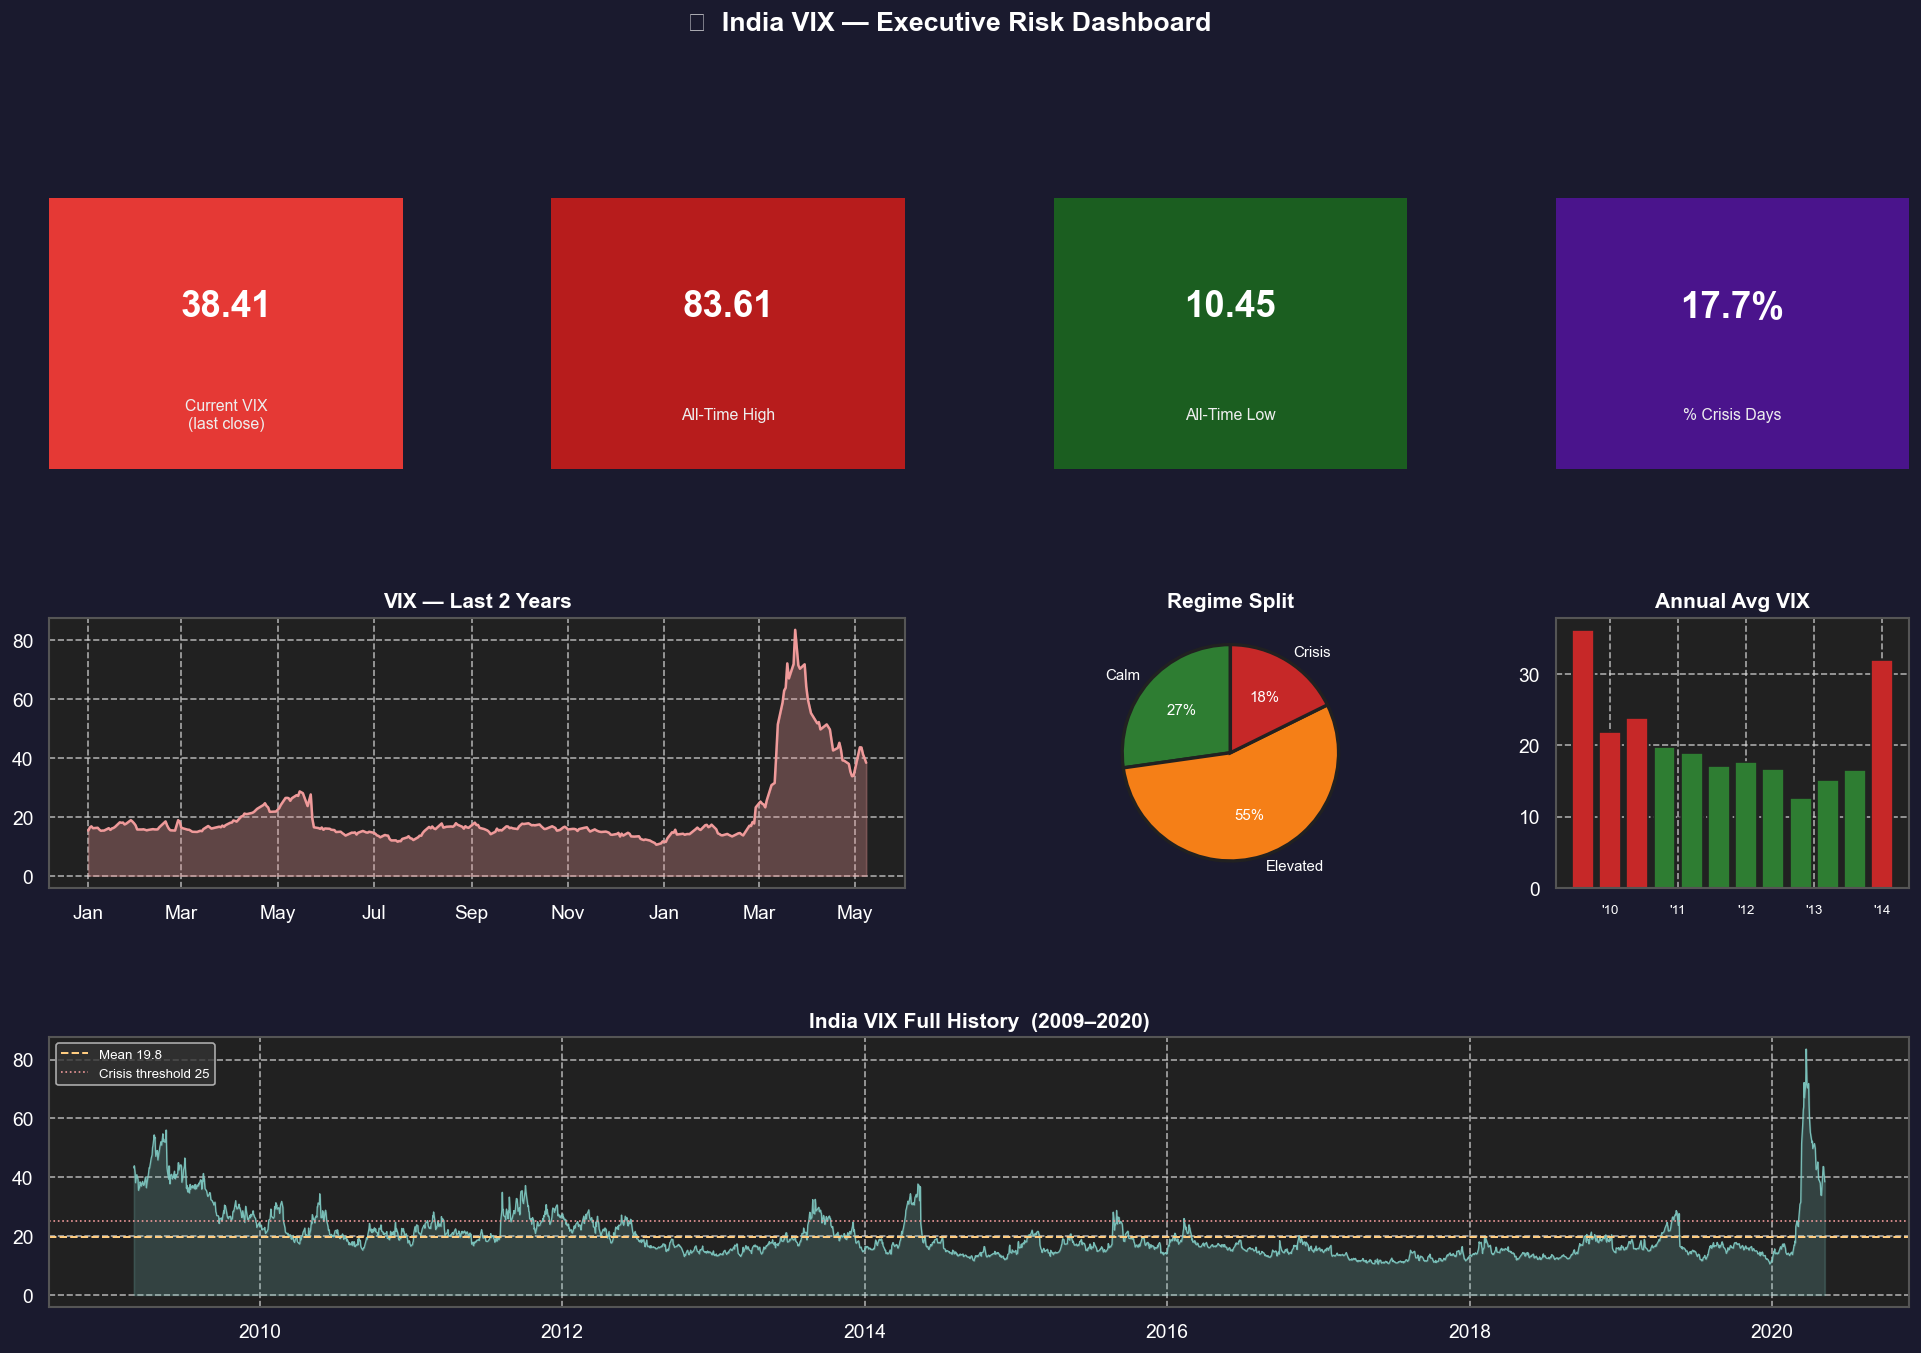

In [18]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#1A1A2E')   # dark finance theme
gs  = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.42)

# ── KPI tiles ─────────────────────────────────────────────────────────────
kpis = [
    ('Current VIX\n(last close)', f'{df.Close.iloc[-1]:.2f}',       '#E53935'),
    ('All-Time High',              f'{df.Close.max():.2f}',           '#B71C1C'),
    ('All-Time Low',               f'{df.Close.min():.2f}',           '#1B5E20'),
    ('% Crisis Days',              f'{(df.regime=="Crisis").mean()*100:.1f}%', '#4A148C'),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, val,   ha='center', va='center', fontsize=22,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center', fontsize=9.5,
            color='#EEEEEE', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

# ── VIX last 2 years ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.set_facecolor('#212121')
recent = df[df['year'] >= df['year'].max()-1]
ax1.plot(recent['Date'], recent['Close'], color='#EF9A9A', linewidth=1.5)
ax1.fill_between(recent['Date'], recent['Close'],
                 alpha=0.3, color='#EF9A9A')
ax1.set_title('VIX — Last 2 Years', fontweight='bold', color='white')
ax1.tick_params(colors='white'); ax1.yaxis.label.set_color('white')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
for sp in ax1.spines.values(): sp.set_color('#555555')

# ── Regime pie ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2])
ax2.set_facecolor('#212121')
rc = df['regime'].value_counts()[['Calm','Elevated','Crisis']]
ax2.pie(rc.values,
        labels=rc.index,
        colors=[REGIME_COLORS[r] for r in rc.index],
        autopct='%1.0f%%', startangle=90,
        textprops={'fontsize':9, 'color':'white'},
        wedgeprops={'edgecolor':'#212121','linewidth':2})
ax2.set_title('Regime Split', fontweight='bold', color='white')

# ── Annual mean bar ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 3])
ax3.set_facecolor('#212121')
ann_m = df.groupby('year')['Close'].mean()
ax3.bar(ann_m.index % 100, ann_m.values,
        color=[PAL['bear'] if v > df.Close.mean() else PAL['bull']
               for v in ann_m.values], edgecolor='#212121')
ax3.set_title('Annual Avg VIX', fontweight='bold', color='white')
ax3.tick_params(colors='white')
ax3.set_xticklabels([f"'{y}" for y in ann_m.index % 100], fontsize=8, color='white')
for sp in ax3.spines.values(): sp.set_color('#555555')

# ── Full history sparkline ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0:4])
ax4.set_facecolor('#212121')
ax4.plot(df['Date'], df['Close'], color='#80CBC4', linewidth=0.8, alpha=0.9)
ax4.fill_between(df['Date'], df['Close'], alpha=0.2, color='#80CBC4')
ax4.axhline(df.Close.mean(), color='#FFCC80', linestyle='--',
            linewidth=1.2, label=f'Mean {df.Close.mean():.1f}')
ax4.axhline(25, color='#EF9A9A', linestyle=':', linewidth=1, label='Crisis threshold 25')
ax4.set_title('India VIX Full History  (2009–2020)', fontweight='bold', color='white')
ax4.tick_params(colors='white')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.legend(fontsize=8, facecolor='#333333', labelcolor='white')
for sp in ax4.spines.values(): sp.set_color('#555555')

fig.suptitle('📊  India VIX — Executive Risk Dashboard',
             fontsize=16, fontweight='bold', color='white', y=1.01)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','dashboard.png'), dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


In [19]:
print('='*65)
print('   INDIA VIX — COMPLETE STATISTICAL SUMMARY')
print('='*65)
print(f'  Period          : {df.Date.min().date()} → {df.Date.max().date()}')
print(f'  Trading days    : {len(df):,}')
print(f'  All-time High   : {df.Close.max():.2f}  ({df.loc[df.Close.idxmax(),"Date"].date()})')
print(f'  All-time Low    : {df.Close.min():.2f}  ({df.loc[df.Close.idxmin(),"Date"].date()})')
print(f'  Overall Mean    : {df.Close.mean():.2f}')
print(f'  Overall Median  : {df.Close.median():.2f}')
print(f'  Std Deviation   : {df.Close.std():.2f}')
print()
print('  Percentiles:')
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f'    {p:3d}th : {df.Close.quantile(p/100):.2f}')
print()
print('  Return Statistics (log returns):')
lr = df.log_return.dropna()
print(f'    Mean daily log return : {lr.mean():.6f}')
print(f'    Std (daily)           : {lr.std():.4f}')
print(f'    Skewness              : {skew(lr):.4f}')
print(f'    Excess Kurtosis       : {kurtosis(lr):.4f}')
print(f'    Max 1-day gain        : {lr.max():.4f} ({lr.max()*100:.2f}%)')
print(f'    Max 1-day loss        : {lr.min():.4f} ({lr.min()*100:.2f}%)')
print()
print('  Regime breakdown:')
for r in ['Calm','Elevated','Crisis']:
    n = (df.regime==r).sum()
    print(f'    {r:<10}: {n:>5} days ({n/len(df)*100:.1f}%)')
print()
print('  Mean-reversion:')
x = df.Close.values[:-1]; y = df.Close.values[1:]
sl, ic, r_val, p_val, _ = stats.linregress(x, y)
print(f'    Lag-1 OLS slope : {sl:.4f}  (mean-rev. speed = {1-sl:.4f})')
print(f'    R²              : {r_val**2:.4f}')
print(f'    p-value         : {p_val:.2e}')
print('='*65)


   INDIA VIX — COMPLETE STATISTICAL SUMMARY
  Period          : 2009-03-02 → 2020-05-08
  Trading days    : 2,769
  All-time High   : 83.61  (2020-03-24)
  All-time Low    : 10.45  (2017-05-25)
  Overall Mean    : 19.77
  Overall Median  : 17.27
  Std Deviation   : 8.06

  Percentiles:
     10th : 13.07
     25th : 14.76
     50th : 17.27
     75th : 22.04
     90th : 28.66
     95th : 36.60
     99th : 51.46

  Return Statistics (log returns):
    Mean daily log return : -0.000063
    Std (daily)           : 0.0518
    Skewness              : 0.4622
    Excess Kurtosis       : 7.3220
    Max 1-day gain        : 0.4969 (49.69%)
    Max 1-day loss        : -0.4144 (-41.44%)

  Regime breakdown:
    Calm      :   754 days (27.2%)
    Elevated  :  1525 days (55.1%)
    Crisis    :   490 days (17.7%)

  Mean-reversion:
    Lag-1 OLS slope : 0.9870  (mean-rev. speed = 0.0130)
    R²              : 0.9753
    p-value         : 0.00e+00
